<!-- STATUS_BLOCK_v1 -->
# exposure_analysis.ipynb — STATUS

**Pipeline position:** Pipeline [4] of [4] — exploratory / figures

**Purpose.**  Plot every facet of foraging behaviour over the experimental window: hourly curves, daily activity, IFI, heading distributions, dose-response. Pre-registered statistical conclusions live in `5g_foraging_effect_model.ipynb`, not here.

**Inputs:**  `data/multi_day/{daily_summary, per_track_indicators, track_geometry, indicators_daily}.csv` + KNMI weather
**Outputs:** figures (inline) only — no CSV writes except `track_geometry.csv` / `heatmap_samples.csv`

### WORKS
- Sections A-O all run end-to-end against the current data
- Reads from `data/flight_data/` via the cell that builds `track_geometry.csv`
- Daily-curve overlay with KNMI temperature

### PENDING
- Indoor T/RH/light from greenhouse sensor (if/when available)
- Add a dose-response section that uses `mean_dbm` from `indicators_daily.csv` directly

## Pipeline flow (canonical)

```
data/flight_data/<date>_system_<sys>/                  ← raw PATS-C output
       │
       ▼
[1] flower_visit_pipeline.ipynb                        slow; run when raw data changes
       └── data/multi_day/flower_visit_summary.csv

[2] multi_day_pipeline.ipynb                           always run after raw data updates
       ├── data/multi_day/daily_summary.csv
       ├── data/multi_day/per_track_indicators.csv
       └── data/multi_day/indicators_daily.csv         ← the file the model consumes

       (uses outputs of [1] + dBm + data transfer)
       │
       ▼
[3] validation.ipynb                                   sensor-integrity QC, run anytime
[3] indicator_validation.ipynb                         baseline-only QC of the 6 indicators
       │
       ▼
[4] exposure_analysis.ipynb                            figures + exploratory plots
[4] 5g_foraging_effect_model.ipynb                     pre-registered verdict, FINAL output
       │
       ▼
[5] statistical_methods.ipynb                          reading guide for [4]; not data-dependent
       │
       ▼
   paper / report
```

**Used in final report:**
- `5g_foraging_effect_model.ipynb` (verdict, mixed-effects model, composite FII)
- `exposure_analysis.ipynb` (figures)
- `validation.ipynb` (Methods)
- `indicator_validation.ipynb` (Methods)
- `statistical_methods.ipynb` (reference)

---


# Exposure analysis: data-transfer ON vs OFF

Loads the per-day and per-track tables produced by `multi_day_pipeline.ipynb` and asks: **does the data-transfer affect bumblebee foraging?**

## Notebook structure

The notebook is split into three conceptually different sections, deliberately not mixed together:

1. **Temporal context.** Time-series of daily activity, every date plotted in chronological order, with shading by condition. This is the only place where BASELINE and ON and OFF appear in the same figure - because the figure is about the *timeline*, not about contrasting conditions.
2. **Pre-exposure baseline characterisation.** What bees did before the transfer was ever turned on (dates before 2026-04-23). Establishes "normal" behaviour and seasonal context. No ON or OFF data appears here.
3. **Experimental contrast: ON vs OFF.** The actual comparison. BASELINE is excluded from these plots - it's a different kind of period (no equipment running yet, different week of the season) and mixing it into a boxplot or histogram invites misleading visual comparisons.

## Experimental design

Three-day-on, three-day-off cycle, anchored at **2026-04-23**. Anything before that is `BASELINE`.

| Period | Dates | Condition |
|---|---|---|
| Pre-exposure | up to 2026-04-22 | BASELINE |
| Cycle 1 ON  | 2026-04-23 to 2026-04-25 | ON |
| Cycle 1 OFF | 2026-04-26 to 2026-04-28 | OFF |
| Cycle 2 ON  | 2026-04-29 to 2026-05-01 | ON |
| Cycle 2 OFF | 2026-05-02 to 2026-05-04 | OFF |
| ... | (3-on / 3-off continues) | |

## Caveats up front

- **Sample size.** 3 days per condition per cycle. Treat large p-values as "we can't see an effect at this sample size", not "no effect exists".
- **Confounds.** Weather, seasonal forage availability, hive maturation. Pull KNMI Wageningen weather data and overlay if effects look suggestive.
- **One-camera-only effects.** A "treatment effect" that only shows on system 900 or 939 is more likely a camera-specific artefact than biology. Always check both cameras.
- **Trip duration is approximate.** PATS-C doesn't track bee identity across detections. We pair each v3 exit with the next un-matched return greedily, which means *individual* trip durations are noise (we can't say "this bee took 30 minutes") - but the *median across many trips* is robust to those swaps because the mismatches cancel symmetrically. So `median_trip_s` is fine as a comparison metric between conditions, just don't read it as a statement about any one bee.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


## 1. Treatment schedule

`condition_for(date)` -> `"BASELINE" | "ON" | "OFF"`. Edit the cycle anchor / length here if the schedule changes.


In [2]:
CYCLE_ANCHOR   = pd.Timestamp("2026-04-23")
CYCLE_ON_DAYS  = 3
CYCLE_OFF_DAYS = 3
CYCLE_LEN      = CYCLE_ON_DAYS + CYCLE_OFF_DAYS

def condition_for(date_like):
    """date_like: anything pd.Timestamp can parse (str, Timestamp, datetime)."""
    d = pd.Timestamp(date_like).normalize()
    if d < CYCLE_ANCHOR:
        return "BASELINE"
    days_since = (d - CYCLE_ANCHOR).days
    cycle_pos  = days_since % CYCLE_LEN
    return "ON" if cycle_pos < CYCLE_ON_DAYS else "OFF"


print("Schedule preview:")
for d in pd.date_range("2026-04-19", "2026-05-28"):
    print(f"  {d.date()}  ->  {condition_for(d)}")


Schedule preview:
  2026-04-19  ->  BASELINE
  2026-04-20  ->  BASELINE
  2026-04-21  ->  BASELINE
  2026-04-22  ->  BASELINE
  2026-04-23  ->  ON
  2026-04-24  ->  ON
  2026-04-25  ->  ON
  2026-04-26  ->  OFF
  2026-04-27  ->  OFF
  2026-04-28  ->  OFF
  2026-04-29  ->  ON
  2026-04-30  ->  ON
  2026-05-01  ->  ON
  2026-05-02  ->  OFF
  2026-05-03  ->  OFF
  2026-05-04  ->  OFF
  2026-05-05  ->  ON
  2026-05-06  ->  ON
  2026-05-07  ->  ON
  2026-05-08  ->  OFF
  2026-05-09  ->  OFF
  2026-05-10  ->  OFF
  2026-05-11  ->  ON
  2026-05-12  ->  ON
  2026-05-13  ->  ON
  2026-05-14  ->  OFF
  2026-05-15  ->  OFF
  2026-05-16  ->  OFF
  2026-05-17  ->  ON
  2026-05-18  ->  ON
  2026-05-19  ->  ON
  2026-05-20  ->  OFF
  2026-05-21  ->  OFF
  2026-05-22  ->  OFF
  2026-05-23  ->  ON
  2026-05-24  ->  ON
  2026-05-25  ->  ON
  2026-05-26  ->  OFF
  2026-05-27  ->  OFF
  2026-05-28  ->  OFF


## 2. Load data


## Now reading V3 multi-day data

This notebook now pulls from `data/multi_day_v3/` (the v3 pipeline output)
rather than the legacy `data/multi_day/`. The data-load cell below applies a
small column-rename shim so all downstream sections (D heatmap, F per-hour,
G anchors, H vertical, I IFI, J temperature, K dashboard, L headings,
M accumulation, N sensitivity, O dose-response, P summary) run unchanged.

A backup of the v1-data-source version is saved alongside as:
`exposure_analysis.backup_before_v3_data_source.ipynb`


In [3]:
# ---------------------------------------------------------------------------
# Data source: V3 multi-day pipeline (data/multi_day_v3/)
# ---------------------------------------------------------------------------
# This notebook was originally written against data/multi_day/ (v1 pipeline).
# It now reads from data/multi_day_v3/ which uses different column names:
#   n_exit_v3      → renamed to n_v3        (so downstream cells keep working)
#   n_return_v3    → renamed to n_returns
#   hive_return_v3 → renamed to hive_return (kept as alias)
# Other shared column names (re_ratio_v3, median_trip_s, hive_exit_v3,
# tortuosity) are identical in v3 so need no rewriting.
#
# Backup of the v1-data-source notebook is at:
#   exposure_analysis.backup_before_v3_data_source.ipynb

DATA_DIR = Path("data/multi_day_v3")

daily  = pd.read_csv(DATA_DIR / "daily_summary.csv")
tracks = pd.read_csv(DATA_DIR / "per_track_indicators.csv", parse_dates=["ts"])

# --- v3 → legacy column aliases (so downstream cells run unchanged) -------
_DAILY_RENAMES  = {"n_exit_v3": "n_v3", "n_return_v3": "n_returns"}
_TRACK_RENAMES  = {"hive_return_v3": "hive_return"}

# Only rename if the v3 column actually exists; keep the original v3 column too
for src, dst in _DAILY_RENAMES.items():
    if src in daily.columns and dst not in daily.columns:
        daily[dst] = daily[src]
for src, dst in _TRACK_RENAMES.items():
    if src in tracks.columns and dst not in tracks.columns:
        tracks[dst] = tracks[src]

daily["condition"]  = daily["date"].apply(condition_for)
tracks["condition"] = tracks["date"].apply(condition_for)

systems = sorted(daily["system_id"].unique())

print(f"Reading from: {DATA_DIR}")
print(f"  daily : {daily.shape}   columns: {len(daily.columns)}")
print(f"  tracks: {tracks.shape}  columns: {len(tracks.columns)}")
print()
print("daily summary by condition:")
print(daily.groupby("condition").agg(
    n_pairs    = ("date",        "size"),
    n_dates    = ("date",        "nunique"),
    total_v3   = ("n_v3",        "sum"),
    total_ret  = ("n_returns",   "sum"),
    median_trip= ("median_trip_s","median"),
).to_string())

print(f"\nper_track rows: {len(tracks):,}  "
      f"({tracks['condition'].value_counts().to_dict()})")


Reading from: data/multi_day_v3
  daily : (82, 16)   columns: 16
  tracks: (66239, 19)  columns: 19

daily summary by condition:
           n_pairs  n_dates  total_v3  total_ret  median_trip
condition                                                    
BASELINE        12       10      1269       1245       3304.0
OFF             34       17      1987       1784       4254.0
ON              36       18      1938       1734       2755.0

per_track rows: 66,239  ({'OFF': 26695, 'ON': 26443, 'BASELINE': 13101})


# Section A - Temporal context

Every date, in chronological order, with condition shading. This is the only figure that shows BASELINE / ON / OFF together: the point of this figure is the *timeline*, not the contrast.


## 3. Daily activity time series

Bar chart per camera. **Red shading** = transfer ON. **Grey shading** = pre-exposure baseline. White = OFF (transfer installed but turned off).

The orange line is the **daytime mean air temperature** (KNMI, 08:00-18:00 mean) on a twin y-axis, so you can see whether activity tracks weather rather than condition.


Using wind file: wind_data_04-09_to_05-27.txt


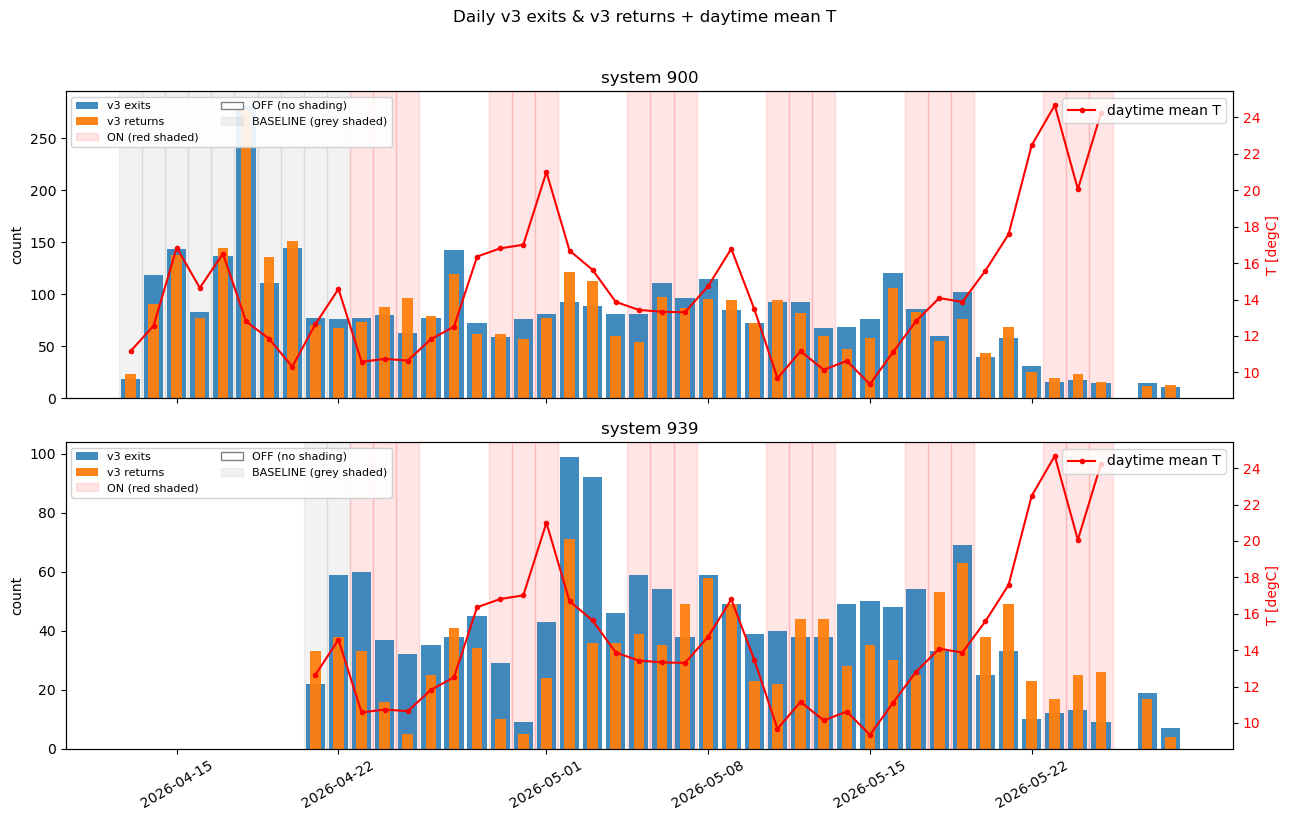

In [4]:
# --- Load daytime mean T from KNMI (graceful fallback if file missing) ----
import re as _re
_wind_dir = Path("../../../data")
def _wind_endkey(p):
    m = _re.findall(r"to_(\d{2})-(\d{2})", p.name)
    return (int(m[0][0]), int(m[0][1])) if m else (0, 0)
_wind_files = sorted(_wind_dir.glob("wind_data_*_to_*.txt"), key=_wind_endkey)
WIND_FILE_A = _wind_files[-1] if _wind_files else _wind_dir / "wind_data_missing.txt"
print(f"Using wind file: {WIND_FILE_A.name}")
if WIND_FILE_A.exists():
    _KNMI_COLS = ["STN","YYYYMMDD","HH","DD","FH","FF","FX","T","T10N","TD",
                  "SQ","Q","DR","RH","P","VV","N","U","WW","IX","M","R","S","O","Y"]
    _raw = pd.read_csv(WIND_FILE_A, comment="#", names=_KNMI_COLS,
                       skipinitialspace=True, na_values=["", " "])
    _raw["ts_utc"]   = (pd.to_datetime(_raw["YYYYMMDD"].astype(int), format="%Y%m%d")
                        + pd.to_timedelta(_raw["HH"].astype(int) - 1, unit="h"))
    _raw["ts_utc"]   = _raw["ts_utc"].dt.tz_localize("UTC")
    _raw["ts_local"] = _raw["ts_utc"].dt.tz_convert("Europe/Amsterdam")
    _raw["date"]     = _raw["ts_local"].dt.date
    _raw["hour"]     = _raw["ts_local"].dt.hour
    _raw["T_C"]      = _raw["T"] / 10.0
    _daytime         = _raw[_raw["hour"].between(8, 17)]
    daily_T_A = (_daytime.groupby("date")["T_C"].mean()
                          .rename("T_mean_day").reset_index())
    daily_T_A["date"] = pd.to_datetime(daily_T_A["date"])
else:
    daily_T_A = None
    print(f"KNMI file not found at {WIND_FILE_A.resolve()} - temperature line will be skipped.")

fig, axes = plt.subplots(len(systems), 1, figsize=(13, 4 * len(systems)),
                          sharex=True, squeeze=False)

for ax, sys_id in zip(axes[:, 0], systems):
    sub = (daily[daily["system_id"] == sys_id]
           .sort_values("date").reset_index(drop=True))
    if sub.empty:
        ax.set_title(f"system {sys_id} - no data")
        continue
    x = pd.to_datetime(sub["date"])
    w = pd.Timedelta(hours=20)

    ax.bar(x, sub["n_v3"],      width=w,            color="tab:blue",   alpha=0.85, label="v3 exits")
    ax.bar(x, sub["n_returns"], width=w * 0.55,     color="tab:orange", alpha=0.95, label="v3 returns")

    for _, row in sub.iterrows():
        d = pd.Timestamp(row["date"])
        if row["condition"] == "ON":
            ax.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12),
                       color="red", alpha=0.10, zorder=0)
        elif row["condition"] == "BASELINE":
            ax.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12),
                       color="grey", alpha=0.10, zorder=0)

    ax.set_title(f"system {sys_id}")
    ax.set_ylabel("count")
    # ---- legend: bars + condition shading swatches ----
    import matplotlib.patches as _mpatches
    _cond_handles = [
        _mpatches.Patch(facecolor="red",   alpha=0.10, edgecolor="red",   label="ON (red shaded)"),
        _mpatches.Patch(facecolor="white",                edgecolor="grey", label="OFF (no shading)"),
        _mpatches.Patch(facecolor="grey",  alpha=0.10, edgecolor="grey",  label="BASELINE (grey shaded)"),
    ]
    _h, _l = ax.get_legend_handles_labels()
    ax.legend(_h + _cond_handles, _l + [p.get_label() for p in _cond_handles],
              loc="upper left", fontsize=8, ncol=2, framealpha=0.9)
    ax.tick_params(axis="x", rotation=30)

    # --- Twin axis: daytime mean T ---
    if daily_T_A is not None:
        ax2 = ax.twinx()
        sub_T = pd.to_datetime(sub["date"]).to_frame(name="date").merge(
            daily_T_A, on="date", how="left")
        ax2.plot(sub_T["date"], sub_T["T_mean_day"],
                 color="red", marker="o", lw=1.5, ms=3,
                 label="daytime mean T", zorder=5)
        ax2.set_ylabel("T [degC]", color="red")
        ax2.tick_params(axis="y", labelcolor="red")
        ax2.legend(loc="upper right")

fig.suptitle("Daily v3 exits & v3 returns + daytime mean T", y=1.02)
plt.tight_layout()
plt.show()


# Section B - Pre-exposure baseline (reference)

A single line of reference numbers from the BASELINE period. Used only to remind you what the natural day-to-day variance looked like before the experiment started — not for direct comparison with ON/OFF (different week of the season, no transmitter, different colony state).

If you want the full baseline characterisation (boxplots, tortuosity, hourly curve), see `exposure_analysis.backup_before_change.ipynb`.


In [5]:
bl = daily[daily["condition"] == "BASELINE"]
if bl.empty:
    print("No baseline data cached.")
else:
    print(f"Baseline window : {bl['date'].min()}  to  {bl['date'].max()}  "
          f"({bl['date'].nunique()} dates, {len(bl)} (date,system) pairs)")
    print(f"Baseline tracks : {(tracks['condition']=='BASELINE').sum():,}")
    print()
    print("Per-system baseline medians:")
    print(bl.groupby("system_id").agg(
        median_v3     = ("n_v3",         "median"),
        median_ret    = ("n_returns",    "median"),
        median_trip_s = ("median_trip_s","median"),
    ).round(1).to_string())


Baseline window : 2026-04-13  to  2026-04-22  (10 dates, 12 (date,system) pairs)
Baseline tracks : 13,101

Per-system baseline medians:
           median_v3  median_ret  median_trip_s
system_id                                      
900            114.5       113.5         3304.0
939             40.5        35.5         5333.5


# Section C - Experimental contrast: ON vs OFF

The actual experimental comparison. **BASELINE is excluded from this section** - we're answering "given the equipment is installed, does turning the transfer on change foraging?", not "do bees behave differently in late April than early May?". Mixing the two questions in one figure is what we want to avoid.


## 4. ON vs OFF box plots


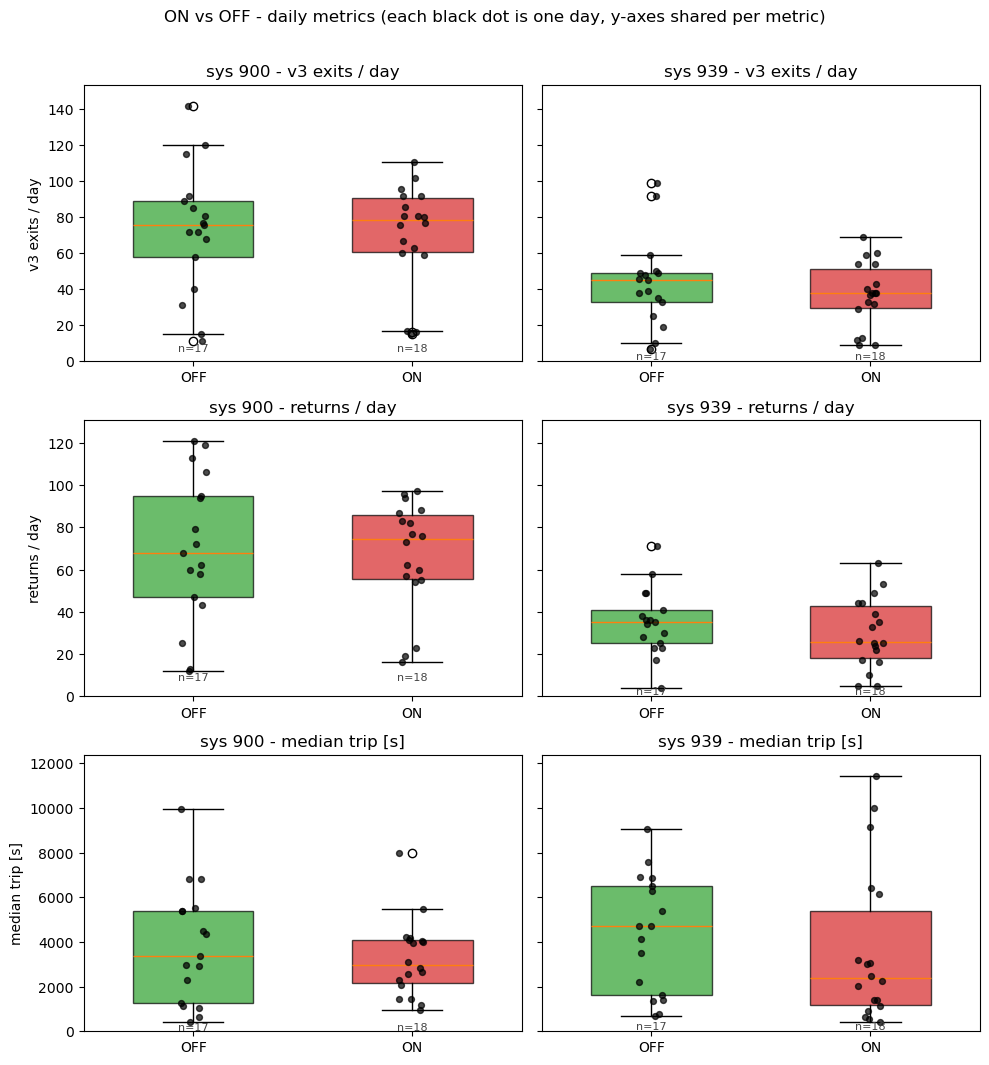

In [6]:
METRICS = [("n_v3",          "v3 exits / day"),
           ("n_returns",     "returns / day"),
           ("median_trip_s", "median trip [s]")]
ORDER   = ["OFF", "ON"]
COLORS  = {"OFF": "tab:green", "ON": "tab:red"}
C_ORDER  = ["OFF", "ON"]

contrast_daily = daily[daily["condition"].isin(ORDER)].copy()

if contrast_daily.empty:
    print("No ON/OFF data yet. Skipping section C.")
else:
    fig, axes = plt.subplots(len(METRICS), len(systems),
                              figsize=(5 * len(systems), 3.5 * len(METRICS)),
                              sharey="row",  # same y-axis across systems per metric
                              squeeze=False)
    for row, (col, label) in enumerate(METRICS):
        # global max for this metric across both systems & both conditions
        ymax = contrast_daily[col].max()
        for c_ax, sys_id in enumerate(systems):
            ax = axes[row, c_ax]
            sub = contrast_daily[contrast_daily["system_id"] == sys_id]
            groups = [sub.loc[sub["condition"] == k, col].dropna().values
                  for k in C_ORDER]
            data = [sub.loc[sub["condition"] == cond, col].dropna() for cond in ORDER]
            bp = ax.boxplot(data, tick_labels=ORDER, patch_artist=True, widths=0.55)
            for patch, cond in zip(bp["boxes"], ORDER):
                patch.set_facecolor(COLORS[cond]); patch.set_alpha(0.7)
            for i, d in enumerate(data):
                ax.scatter(np.full(len(d), i + 1) + np.random.uniform(-0.06, 0.06, len(d)),
                           d, color="black", s=18, alpha=0.7, zorder=3)
            ax.set_title(f"sys {sys_id} - {label}")
            for i, vals in enumerate(groups, start=1):
                if len(vals):
                    ax.text(i, ax.get_ylim()[0],
                            f"n={len(vals)}", ha="center", va="bottom",
                            fontsize=8, color="#444")
            if c_ax == 0:
                ax.set_ylabel(label)
            ax.set_ylim(0, ymax * 1.08 if ymax > 0 else 1)
            
    fig.suptitle("ON vs OFF - daily metrics (each black dot is one day, y-axes shared per metric)",
                 y=1.01)
    plt.tight_layout()
    plt.show()


## 5. ON vs OFF tortuosity

Per-track tortuosity distributions. If bees navigate less efficiently when the transfer is on, the ON histogram should sit slightly to the right of OFF.


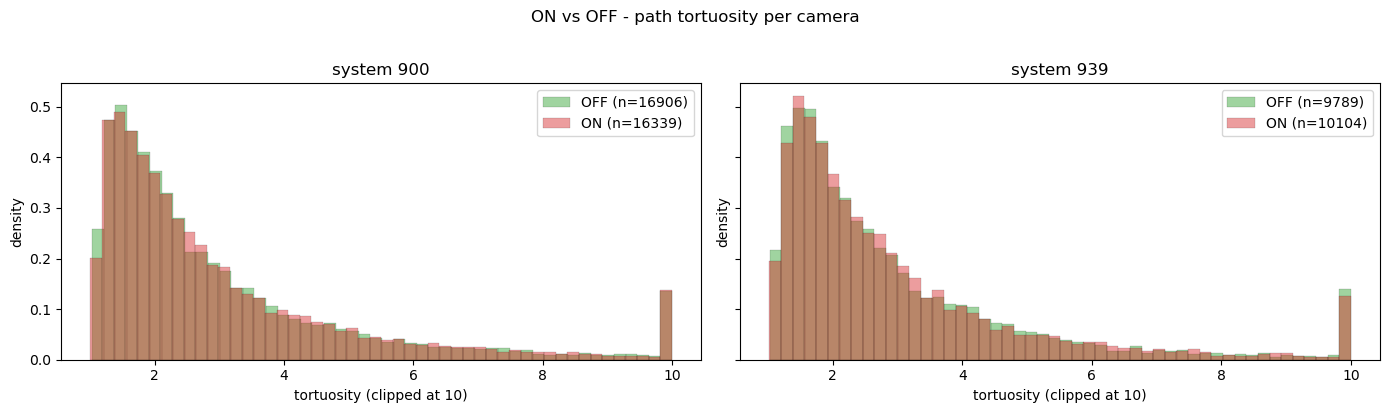

In [7]:
contrast_tracks = tracks[tracks["condition"].isin(["ON", "OFF"])].copy()

if contrast_tracks.empty:
    print("No ON/OFF tracks yet. Skipping.")
else:
    fig, axes = plt.subplots(1, len(systems), figsize=(7 * len(systems), 4),
                              sharey=True, squeeze=False)
    for ax, sys_id in zip(axes[0], systems):
        sub = contrast_tracks[(contrast_tracks["system_id"] == sys_id) &
                              contrast_tracks["tortuosity"].notna()]
        for cond, color in [("OFF", "tab:green"), ("ON", "tab:red")]:
            vals = sub.loc[sub["condition"] == cond, "tortuosity"].clip(upper=10)
            if len(vals) == 0:
                continue
            ax.hist(vals, bins=50, alpha=0.45, color=color, density=True,
                    label=f"{cond} (n={len(vals)})", edgecolor="black", linewidth=0.2)
        ax.set_xlabel("tortuosity (clipped at 10)")
        ax.set_ylabel("density")
        ax.set_title(f"system {sys_id}")
        ax.legend()
    fig.suptitle("ON vs OFF - path tortuosity per camera", y=1.02)
    plt.tight_layout()
    plt.show()


## 6. ON vs OFF hourly curve

Average hourly exit rate, ON vs OFF, with BASELINE plotted as a faint dashed line for *visual reference only* - not as a third condition in the comparison.


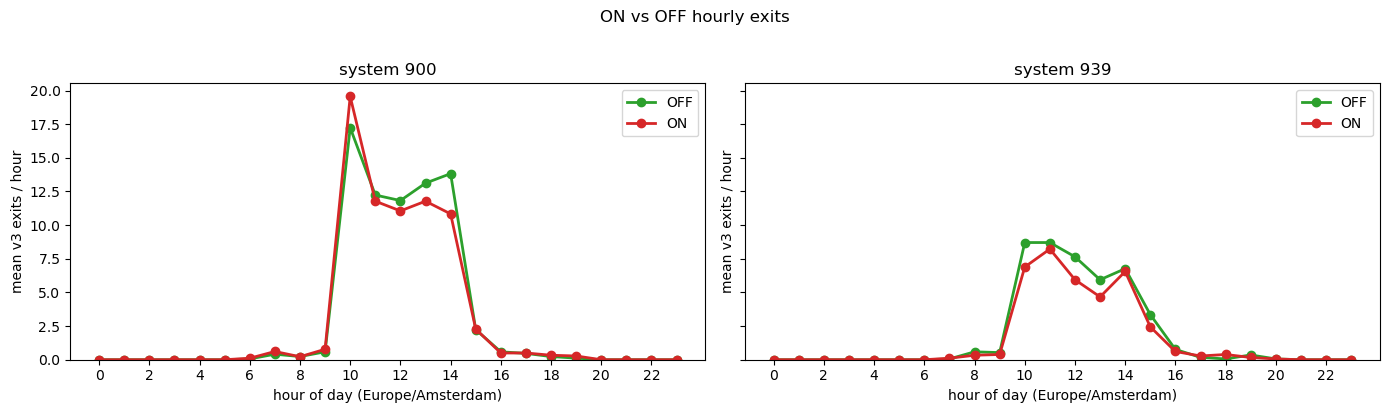

In [8]:
def hourly_mean_curve(df, system_id, condition):
    """Mean v3-exits-per-hour curve over all dates with the given condition."""
    sub = df[(df["system_id"] == system_id) &
             (df["condition"] == condition) &
             (df["hive_exit_v3"] == True) &
             df["ts"].notna()].copy()
    if sub.empty:
        return None
    sub["hour"] = sub["ts"].dt.hour
    sub["date"] = sub["ts"].dt.date
    counts = (sub.groupby(["date", "hour"]).size()
              .unstack(fill_value=0)
              .reindex(columns=range(24), fill_value=0))
    return counts.mean(axis=0)


if contrast_tracks.empty:
    print("No ON/OFF tracks yet. Skipping.")
else:
    fig, axes = plt.subplots(1, len(systems), figsize=(7 * len(systems), 4),
                              sharey=True, squeeze=False)
    for ax, sys_id in zip(axes[0], systems):
        for cond, color in [("OFF", "tab:green"), ("ON", "tab:red")]:
            curve = hourly_mean_curve(tracks, sys_id, cond)
            if curve is None:
                continue
            ax.plot(curve.index, curve.values, "o-", color=color, lw=2,
                    label=cond)
        ax.set_xticks(range(0, 24, 2))
        ax.set_xlabel("hour of day (Europe/Amsterdam)")
        ax.set_ylabel("mean v3 exits / hour")
        ax.set_title(f"system {sys_id}")
        ax.set_ylim(bottom=0)
        ax.legend()
    fig.suptitle("ON vs OFF hourly exits", y=1.02)
    plt.tight_layout()
    plt.show()


## 7. Statistical tests (ON vs OFF)

Two-sided Mann-Whitney U for each metric, per camera. Non-parametric because daily counts don't have to be Gaussian and we have small samples. **Compares ON vs OFF only - BASELINE is not included** because it's a different kind of period (different week of the season, no transmitter installed).

**How to read the p-values.** With 3-6 days per condition, anything p < 0.05 is plausible but not bulletproof - it's worth a closer look but not a publishable claim on its own. p > 0.20 means "we can't distinguish ON from OFF at this sample size". Add more cycles before drawing strong conclusions.


In [9]:
from scipy import stats

print(f"{'metric':25s} {'system':>6s} {'ON med':>10s} {'OFF med':>10s} {'p (MWU)':>10s} {'n_on':>5s} {'n_off':>5s}")
print("-" * 78)
for sys_id in systems:
    sub = daily[(daily["system_id"] == sys_id) & daily["condition"].isin(["ON", "OFF"])]
    for col, label in [("n_v3",          "n_v3"),
                       ("n_returns",     "n_returns"),
                       ("median_trip_s", "median_trip_s")]:
        on  = sub.loc[sub["condition"] == "ON",  col].dropna()
        off = sub.loc[sub["condition"] == "OFF", col].dropna()
        if len(on) == 0 or len(off) == 0:
            print(f"{label:25s} {sys_id:6d} {'-':>10s} {'-':>10s} {'n/a':>10s} {len(on):>5d} {len(off):>5d}")
            continue
        u, p = stats.mannwhitneyu(on, off, alternative="two-sided")
        print(f"{label:25s} {sys_id:6d} {on.median():10.2f} {off.median():10.2f} {p:10.3f} {len(on):>5d} {len(off):>5d}")

print()
for sys_id in systems:
    sub = tracks[(tracks["system_id"] == sys_id) &
                 tracks["condition"].isin(["ON", "OFF"]) &
                 tracks["tortuosity"].notna()]
    on  = sub.loc[sub["condition"] == "ON",  "tortuosity"]
    off = sub.loc[sub["condition"] == "OFF", "tortuosity"]
    if len(on) == 0 or len(off) == 0:
        print(f"{'tortuosity (per track)':25s} {sys_id:6d} insufficient data")
        continue
    u, p = stats.mannwhitneyu(on, off, alternative="two-sided")
    print(f"{'tortuosity (per track)':25s} {sys_id:6d} {on.median():10.2f} {off.median():10.2f} {p:10.3f} {len(on):>5d} {len(off):>5d}")


metric                    system     ON med    OFF med    p (MWU)  n_on n_off
------------------------------------------------------------------------------
n_v3                         900      78.50      76.00      0.947    18    17
n_returns                    900      74.50      68.00      0.843    18    17
median_trip_s                900    2983.00    3391.00      0.586    18    17
n_v3                         939      38.00      45.00      0.509    18    17
n_returns                    939      25.50      35.00      0.346    18    17
median_trip_s                939    2364.50    4722.00      0.299    18    17

tortuosity (per track)       900       2.31       2.28      0.324 16339 16906
tortuosity (per track)       939       2.30       2.30      0.788 10104  9789


# Section D - Heading at frame entry/exit

Bumblebees enter and leave the camera FOV either *at the hive* or *at the edge of the field of view*. The hive endpoints are already covered by exit / return classification - what's interesting here is the **frame-edge endpoints**: a track that begins away from the hive must have *entered* the FOV through one of the camera's outer faces, and a track that ends away from the hive must have *left* through one. The direction of motion at that moment tells us where the bee was coming from / heading to.

We define heading on the **horizontal plane** (top-down), in degrees:

- 0° = +X (camera-frame east)
- 90° = +Y (camera-frame north)

For an *entry*, heading is `atan2(y[5] - y[0], x[5] - x[0])` — the direction the bee was moving when it appeared in the FOV. For an *exit*, it's the same delta over the last 5 frames.

A track is classified as **frame-entry** (vs hive-exit) if the first-sample distance to the hive is greater than `TOL` (0.10 m). Same for frame-exit.

If turning the data transfer ON changes navigation, we'd expect to see the rose plot tilt — fewer bees coming from / going to a particular bearing, or more dispersion overall. If it doesn't change, the rose plots will look identical.


## D.1 Build the per-track geometry table

This cell reads each `tracks/{uid}.csv` in the cache, computes first/last sample positions, classifies the entry / exit endpoint as `hive` or `frame`, and computes the heading (horizontal, degrees). It also stores **subsampled XY** for the heatmap in section E.

Heavy on first run (~30 s for 17 days × 2 systems). Skips entirely if `track_geometry.csv` already exists.


In [10]:
import numpy as np
from pathlib import Path

GEOM_CSV    = Path("data/multi_day/track_geometry.csv")
HEATMAP_CSV = Path("data/multi_day/heatmap_samples.csv")

# Constants matching multi_day_pipeline.ipynb / components.ipynb
TOL          = 0.10
HEAD_FRAMES  = 5
HIVE_BY_SYSTEM = {
    900: np.array([-0.04,  -0.665, -1.195]),
    939: np.array([-0.086, -0.828, -1.045]),
}
HEATMAP_DECIMATION = 10  # keep every Nth valid sample

# Read raw recordings from data/flight_data/ - the cache is bypassed because
# it has been out of date (missing 4/14-4/18 for sys 900).
DATA_BASE = Path("../../../data/flight_data")
import re
folder_re = re.compile(r"^(\d{4}-\d{2}-\d{2})_system_(\d+)$")


def heading_deg(p_far, p_near):
    """Bearing in degrees from p_near to p_far in the XY plane.
    0° = +X, 90° = +Y. Returns NaN if motion is degenerate."""
    dx = p_far[0] - p_near[0]
    dy = p_far[1] - p_near[1]
    if abs(dx) < 1e-9 and abs(dy) < 1e-9:
        return np.nan
    return float(np.degrees(np.arctan2(dy, dx)))


def collect():
    """Walk data/flight_data/, compute per-track geometry and heatmap samples."""
    rows, samples = [], []
    folders = sorted(DATA_BASE.iterdir()) if DATA_BASE.exists() else []
    for f in folders:
        m = folder_re.match(f.name)
        if not m:
            continue
        date_str, sid_str = m.group(1), m.group(2)
        sid = int(sid_str)
        if sid not in HIVE_BY_SYSTEM:
            continue
        hive = HIVE_BY_SYSTEM[sid]

        ft_csv = f / "flight_tracks.csv"
        if not ft_csv.exists():
            continue

        try:
            ft = pd.read_csv(ft_csv,
                             usecols=["detection_uid", "pos_valid_insect",
                                      "posX_insect", "posY_insect", "posZ_insect",
                                      "elapsed"])
        except Exception as e:
            print(f"  skip {f.name}: {e}")
            continue

        ft = ft[ft["pos_valid_insect"] == 1]
        if len(ft) == 0:
            continue

        for uid, grp in ft.groupby("detection_uid"):
            grp = grp.sort_values("elapsed")
            if len(grp) < HEAD_FRAMES + 1:
                continue
            xyz = grp[["posX_insect", "posY_insect", "posZ_insect"]].to_numpy(float)
            p0, pn = xyz[0], xyz[-1]
            d0 = float(np.linalg.norm(p0 - hive))
            dn = float(np.linalg.norm(pn - hive))

            h_entry = heading_deg(xyz[HEAD_FRAMES], p0)
            h_exit  = heading_deg(pn, xyz[-HEAD_FRAMES - 1])

            rows.append({
                "date": date_str, "system_id": sid,
                "uid": int(uid),
                "n_valid":   len(grp),
                "x_first":   p0[0], "y_first":   p0[1], "z_first":   p0[2],
                "x_last":    pn[0], "y_last":    pn[1], "z_last":    pn[2],
                "d_hive_first": d0, "d_hive_last":  dn,
                "entry_at_hive": d0 <= TOL,
                "exit_at_hive":  dn <= TOL,
                "heading_entry_deg": h_entry,
                "heading_exit_deg":  h_exit,
            })

            # Decimated XY samples for the heatmap
            for x, y in xyz[::HEATMAP_DECIMATION, :2]:
                samples.append((date_str, sid, x, y))
    return rows, samples


# Decide whether to re-scan: regenerate if either CSV is missing OR if the
# cache's date coverage is narrower than what data/flight_data/ now offers.
def _need_rescan():
    if not (GEOM_CSV.exists() and HEATMAP_CSV.exists()):
        return True, "missing CSV"
    try:
        cached_dates = set(pd.read_csv(GEOM_CSV, usecols=["date"])["date"].unique())
    except Exception:
        return True, "cache unreadable"
    source_dates = set()
    if DATA_BASE.exists():
        for f in DATA_BASE.iterdir():
            m = folder_re.match(f.name)
            if m: source_dates.add(m.group(1))
    missing = source_dates - cached_dates
    if missing:
        return True, f"source has {len(missing)} dates not in cache: {sorted(missing)[:3]}..."
    return False, "cache covers all source dates"

rescan, why = _need_rescan()
if rescan:
    print(f"Re-scanning data/flight_data/ ({why}) - takes ~30 s...")
    rows, samps = collect()
    geom    = pd.DataFrame(rows)
    samples = pd.DataFrame(samps, columns=["date", "system_id", "x", "y"])
    GEOM_CSV.parent.mkdir(parents=True, exist_ok=True)
    geom.to_csv(GEOM_CSV, index=False)
    samples.to_csv(HEATMAP_CSV, index=False)
    print(f"Wrote {GEOM_CSV} ({len(geom)} tracks) "
          f"and {HEATMAP_CSV} ({len(samples)} samples)")
else:
    print(f"Loading cached {GEOM_CSV} ({GEOM_CSV.stat().st_size//1024} KB) "
          f"and {HEATMAP_CSV} ({HEATMAP_CSV.stat().st_size//1024} KB) - "
          f"{why}")
    geom    = pd.read_csv(GEOM_CSV)
    samples = pd.read_csv(HEATMAP_CSV)

geom["date"]      = pd.to_datetime(geom["date"])
samples["date"]   = pd.to_datetime(samples["date"])
geom["condition"]    = geom["date"].apply(condition_for)
samples["condition"] = samples["date"].apply(condition_for)

print()
print("Endpoint breakdown:")
print(pd.crosstab([geom["system_id"], geom["entry_at_hive"]],
                  geom["exit_at_hive"], margins=True,
                  rownames=["system_id", "entry_at_hive"],
                  colnames=["exit_at_hive"]))


Loading cached data/multi_day/track_geometry.csv (11218 KB) and data/multi_day/heatmap_samples.csv (45346 KB) - cache covers all source dates

Endpoint breakdown:
exit_at_hive             False  True    All
system_id entry_at_hive                    
900       False          35150  6098  41248
          True            4292     3   4295
939       False          17306  2265  19571
          True            2074     3   2077
All                      58822  8369  67191


## D.2 Frame-entry headings — ON vs OFF

Polar histogram of bearings at which bees first appeared in each camera. **Tracks that started at the hive (hive exits) are excluded** — the rose only contains tracks where the bee flew into the FOV from outside.

If wind direction shifts entry bearings (and ON had higher wind than OFF), we'd expect a tilt. If the transfer affects orientation directly, we'd expect *more spread* (less directional bias) when ON.


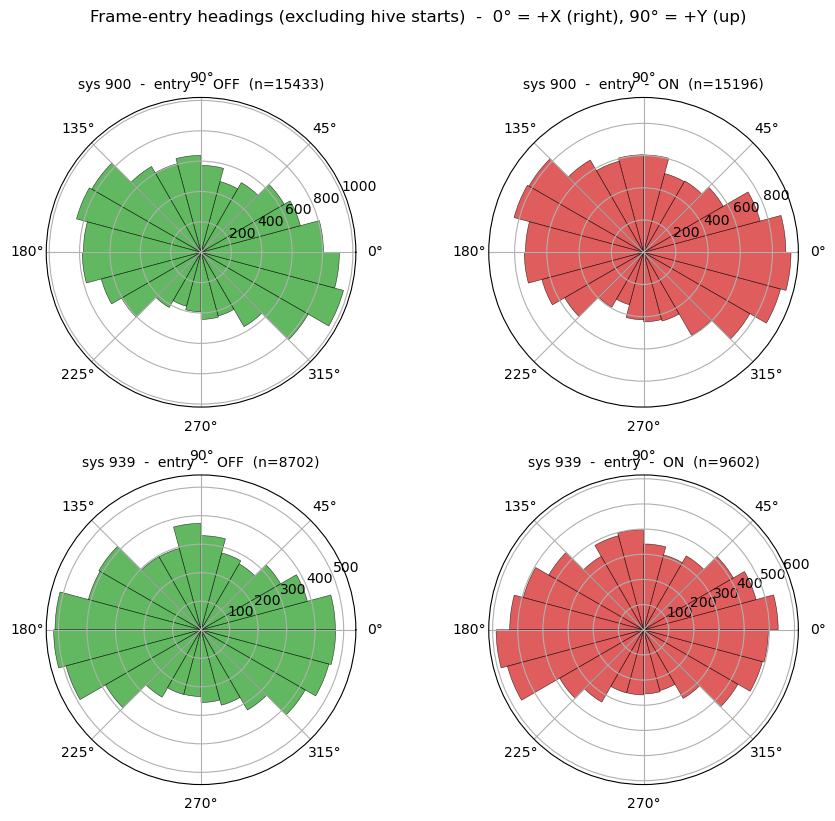

In [11]:
def rose_subplot(ax, headings_deg, title, color, n_bins=24):
    """Draw a polar rose histogram."""
    h = headings_deg.dropna()
    if len(h) == 0:
        ax.set_title(f"{title}\n(no data)", fontsize=10)
        return
    bins = np.linspace(-180, 180, n_bins + 1)
    counts, edges = np.histogram(h, bins=bins)
    centers = np.deg2rad((edges[:-1] + edges[1:]) / 2)
    width   = np.deg2rad(np.diff(edges))
    ax.bar(centers, counts, width=width, color=color, alpha=0.75,
           edgecolor="black", linewidth=0.4)
    ax.set_theta_zero_location("E")          # 0° = +X = right
    ax.set_theta_direction(1)                # CCW (math convention)
    ax.set_title(f"{title}  (n={len(h)})", fontsize=10)


frame_entries = geom[~geom["entry_at_hive"]]
fig, axes = plt.subplots(len(systems), 2,
                         figsize=(9, 4 * len(systems)),
                         subplot_kw=dict(polar=True), squeeze=False)
for r, sid in enumerate(systems):
    sub = frame_entries[frame_entries["system_id"] == sid]
    rose_subplot(axes[r, 0],
                 sub.loc[sub["condition"] == "OFF", "heading_entry_deg"],
                 f"sys {sid}  -  entry  -  OFF", COLORS["OFF"])
    rose_subplot(axes[r, 1],
                 sub.loc[sub["condition"] == "ON",  "heading_entry_deg"],
                 f"sys {sid}  -  entry  -  ON",  COLORS["ON"])
fig.suptitle("Frame-entry headings (excluding hive starts)  -  0° = +X (right), 90° = +Y (up)",
             y=1.02)
plt.tight_layout()
plt.show()


## D.3 Frame-exit headings — ON vs OFF

Same idea, but for the *direction the bee was moving as it left the FOV*. Hive returns are excluded.


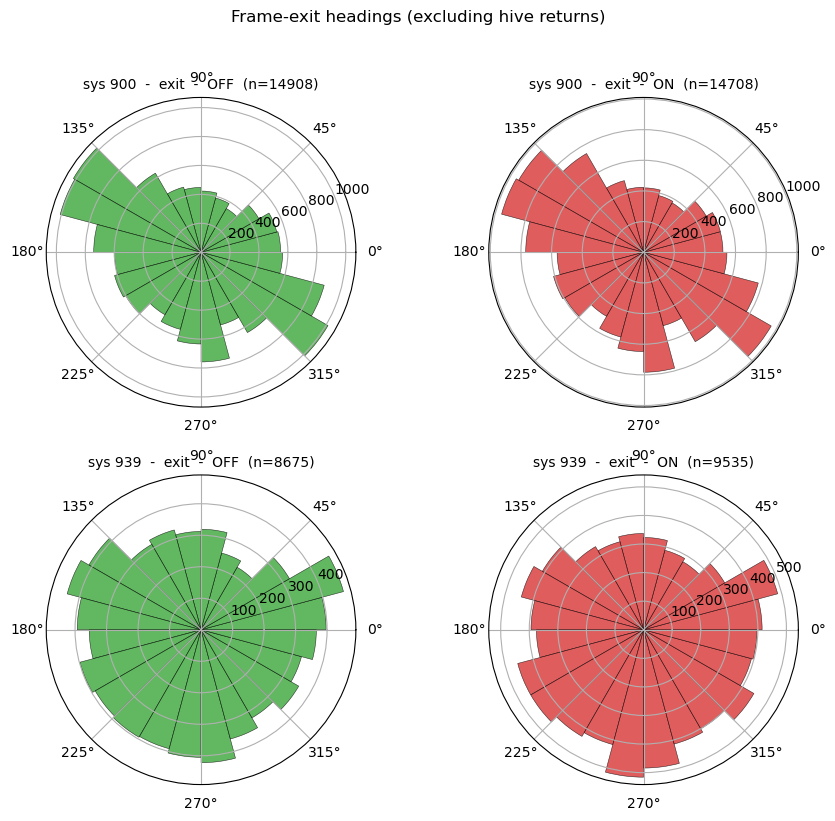

In [12]:
frame_exits = geom[~geom["exit_at_hive"]]
fig, axes = plt.subplots(len(systems), 2,
                         figsize=(9, 4 * len(systems)),
                         subplot_kw=dict(polar=True), squeeze=False)
for r, sid in enumerate(systems):
    sub = frame_exits[frame_exits["system_id"] == sid]
    rose_subplot(axes[r, 0],
                 sub.loc[sub["condition"] == "OFF", "heading_exit_deg"],
                 f"sys {sid}  -  exit  -  OFF", COLORS["OFF"])
    rose_subplot(axes[r, 1],
                 sub.loc[sub["condition"] == "ON",  "heading_exit_deg"],
                 f"sys {sid}  -  exit  -  ON",  COLORS["ON"])
fig.suptitle("Frame-exit headings (excluding hive returns)", y=1.02)
plt.tight_layout()
plt.show()


## D.4 Is the heading distribution different?

Eyeballing rose plots is unreliable. Two metrics per (system, condition):

- **Mean resultant length R.** R = | mean(e^{iθ}) |, between 0 and 1. R = 1 means all headings perfectly aligned, R = 0 means uniform around the circle. A drop in R when going ON → bees less directional, more disoriented.
- **Mean direction.** atan2 of the mean unit vector — the typical bearing.

A two-sample circular test would be the right thing here, but for now we just print the numbers per condition and let you eyeball whether ON and OFF differ in spread or mean direction.


In [13]:
def circ_stats(headings_deg):
    h = headings_deg.dropna()
    if len(h) == 0:
        return float("nan"), float("nan"), 0
    rad = np.deg2rad(h.values)
    R   = float(np.abs(np.mean(np.exp(1j * rad))))
    mean_dir = float(np.degrees(np.angle(np.mean(np.exp(1j * rad)))))
    return R, mean_dir, len(h)

print("Frame-ENTRY headings (ON vs OFF):")
print(f"  {'sys':>4s} {'cond':>10s} {'mean dir':>12s} {'R':>8s} {'n':>6s}")
for sid in systems:
    sub = frame_entries[frame_entries["system_id"] == sid]
    for cond in ["OFF", "ON"]:
        R, md_, n = circ_stats(sub.loc[sub["condition"] == cond, "heading_entry_deg"])
        print(f"  {sid:>4d} {cond:>10s} {md_:>11.1f}° {R:>8.3f} {n:>6d}")

print("\nFrame-EXIT headings (ON vs OFF):")
print(f"  {'sys':>4s} {'cond':>10s} {'mean dir':>12s} {'R':>8s} {'n':>6s}")
for sid in systems:
    sub = frame_exits[frame_exits["system_id"] == sid]
    for cond in ["OFF", "ON"]:
        R, md_, n = circ_stats(sub.loc[sub["condition"] == cond, "heading_exit_deg"])
        print(f"  {sid:>4d} {cond:>10s} {md_:>11.1f}° {R:>8.3f} {n:>6d}")


Frame-ENTRY headings (ON vs OFF):
   sys       cond     mean dir        R      n
   900        OFF        70.0°    0.052  15433
   900         ON        61.7°    0.063  15196
   939        OFF       136.7°    0.023   8702
   939         ON       118.6°    0.046   9602

Frame-EXIT headings (ON vs OFF):
   sys       cond     mean dir        R      n
   900        OFF      -126.2°    0.074  14908
   900         ON      -132.8°    0.077  14708
   939        OFF      -120.3°    0.055   8675
   939         ON       -99.5°    0.083   9535


# Section E - Spatial occupancy heatmap

Top-down (XY) 2D histogram of all valid flight samples, one panel per (system, condition). Brighter cells = more frames spent there. The hive is marked with a black cross.

This visualises *where* in the FOV the bees fly, which is a different question from how *many* bees fly (Section A). If ON suppresses certain regions of the FOV, we'd see darker cells in those regions on the ON panel.

The display window is a fixed **±2 m around the hive** for each camera. PATS-C tracks occasionally produce wild outlier samples (positions of ±10 m or more) that would blow up the auto-extent and wash out the actual flight area; clipping them out is intentional. Each track was decimated to every 10th valid frame before plotting (set in D.1) — absolute brightness is therefore in *decimated frames* per cell, but relative comparisons across panels with comparable sample counts are still meaningful.


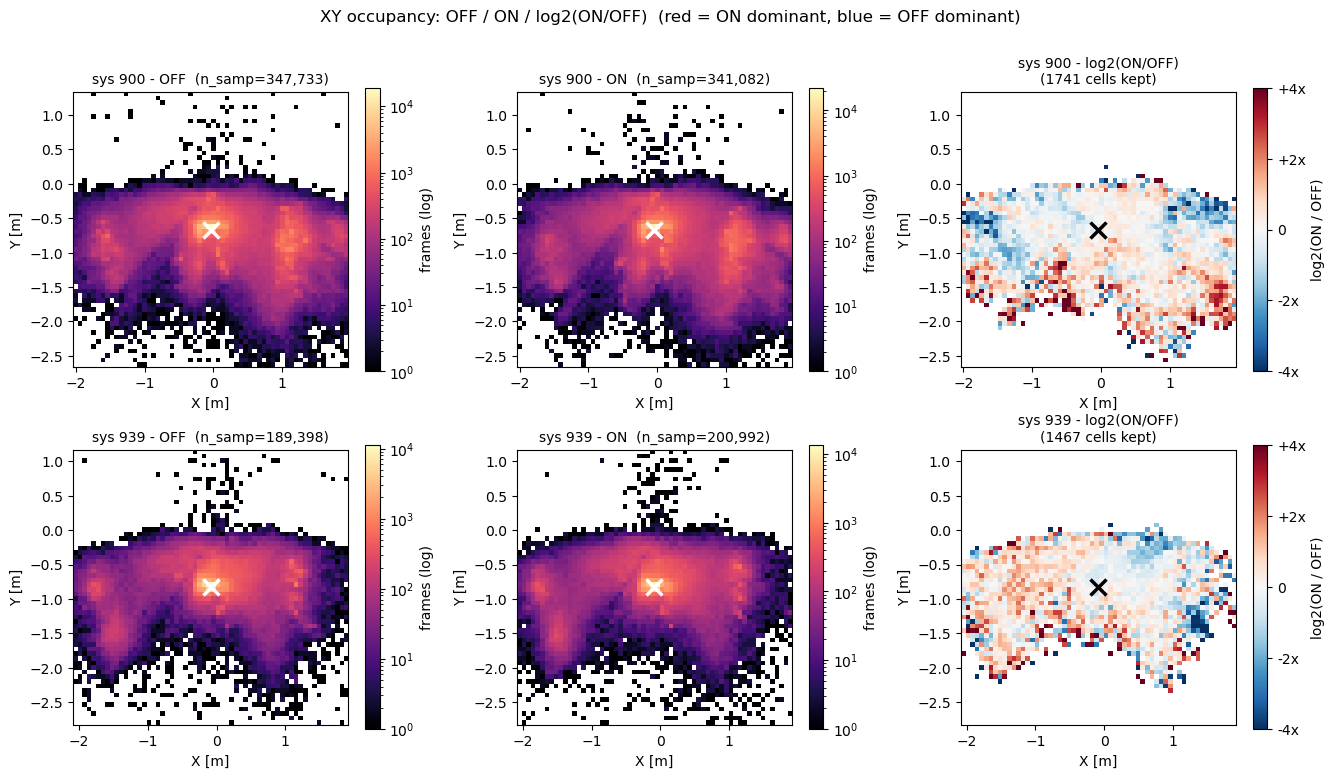

In [14]:
from matplotlib.colors import LogNorm, TwoSlopeNorm

# Window around each camera's hive. PATS-C FOV is ~±2 m around the hive;
# anything beyond that is almost certainly a tracking artefact. Using a fixed
# window per system means brightness IS comparable across OFF / ON.
HM_HALF_X = 2.0    # m, ± from hive in X
HM_HALF_Y = 2.0    # m, ± from hive in Y
HM_BINS   = 60
DIFF_MIN_SAMPLES = 5   # mask diff cells with < this in both conditions
DIFF_LOG2_CLIP   = 2.0 # ±2 = clip ON/OFF ratios to 4x (anything bigger is noise)

CONDS = ["OFF", "ON"]

# 3 columns now: OFF | ON | log2(ON/OFF)
fig, axes = plt.subplots(len(systems), 3,
                         figsize=(13.5, 3.8 * len(systems)),
                         squeeze=False)

for r, sid in enumerate(systems):
    hive_xy  = HIVE_BY_SYSTEM[sid][:2]
    extent_x = (hive_xy[0] - HM_HALF_X, hive_xy[0] + HM_HALF_X)
    extent_y = (hive_xy[1] - HM_HALF_Y, hive_xy[1] + HM_HALF_Y)

    h_by_cond = {}
    for c_idx, cond in enumerate(CONDS):
        ax = axes[r, c_idx]
        sub = samples[(samples["system_id"] == sid) & (samples["condition"] == cond)]
        in_window = ((sub["x"].between(*extent_x)) & (sub["y"].between(*extent_y)))
        sub = sub[in_window]

        if sub.empty:
            ax.set_title(f"sys {sid} - {cond}\n(no data)")
            ax.set_xlim(extent_x); ax.set_ylim(extent_y)
            h_by_cond[cond] = None
            continue
        h, xedges, yedges = np.histogram2d(
            sub["x"], sub["y"], bins=HM_BINS,
            range=[extent_x, extent_y])
        h_by_cond[cond] = h
        im = ax.imshow(h.T, origin="lower", cmap="magma",
                       extent=(*extent_x, *extent_y),
                       norm=LogNorm(vmin=1, vmax=max(h.max(), 1)),
                       aspect="equal")
        ax.plot(hive_xy[0], hive_xy[1], "wx",
                markersize=12, markeredgewidth=2.5)
        ax.set_title(f"sys {sid} - {cond}  (n_samp={len(sub):,})", fontsize=10)
        ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]")
        plt.colorbar(im, ax=ax, label="frames (log)")

    # ── Difference panel ────────────────────────────────────────────────────
    ax_d = axes[r, 2]
    h_off = h_by_cond.get("OFF"); h_on = h_by_cond.get("ON")
    if h_off is None or h_on is None:
        ax_d.set_title(f"sys {sid} - log2(ON/OFF)\n(missing data)")
        ax_d.set_xlim(extent_x); ax_d.set_ylim(extent_y)
    else:
        # Normalise each to per-cell *fraction* of samples, so different totals
        # don't bias the comparison.
        p_off = h_off / max(h_off.sum(), 1)
        p_on  = h_on  / max(h_on.sum(),  1)

        # Mask cells where both conditions have very few samples
        sparse = (h_off < DIFF_MIN_SAMPLES) & (h_on < DIFF_MIN_SAMPLES)

        eps   = 1e-9
        ratio = np.log2((p_on + eps) / (p_off + eps))
        ratio = np.clip(ratio, -DIFF_LOG2_CLIP, DIFF_LOG2_CLIP)
        ratio = np.where(sparse, np.nan, ratio)

        im_d = ax_d.imshow(ratio.T, origin="lower", cmap="RdBu_r",
                           extent=(*extent_x, *extent_y),
                           vmin=-DIFF_LOG2_CLIP, vmax=DIFF_LOG2_CLIP,
                           aspect="equal")
        ax_d.plot(hive_xy[0], hive_xy[1], "kx",
                  markersize=12, markeredgewidth=2.5)
        n_cells_kept = int(np.isfinite(ratio).sum())
        ax_d.set_title(f"sys {sid} - log2(ON/OFF)\n({n_cells_kept} cells kept)", fontsize=10)
        ax_d.set_xlabel("X [m]"); ax_d.set_ylabel("Y [m]")
        cb = plt.colorbar(im_d, ax=ax_d, label="log2(ON / OFF)")
        cb.ax.set_yticks([-DIFF_LOG2_CLIP, -1, 0, 1, DIFF_LOG2_CLIP])
        cb.ax.set_yticklabels([f"-{int(2**DIFF_LOG2_CLIP)}x", "-2x", "0", "+2x", f"+{int(2**DIFF_LOG2_CLIP)}x"])

fig.suptitle("XY occupancy: OFF / ON / log2(ON/OFF)  (red = ON dominant, blue = OFF dominant)",
             y=1.01)
plt.tight_layout()
plt.show()


**Reading the heatmap.**

The first two columns show absolute occupancy (log scale, frames per cell). The third column is **log2(ON / OFF)** for each cell — a true difference plot. Cells masked grey have too few samples in both conditions (< 5 frames each) to interpret. Cells red mean *bees spent more of their time here on ON days*; blue means *more time here on OFF days*. Saturation of red/blue is clipped at ±2 = a 4× ratio (anything bigger is almost certainly noise from the decimated sample, not biology).

What to look for:

- A *coherent red cluster* away from the hive on ON would mean ON-state foraging is concentrated in a different direction than OFF.
- A *coherent blue cluster* on the OFF side of the hive that disappears on ON would mean an exit corridor is being suppressed.
- Salt-and-pepper red/blue with no spatial structure = noise from low counts in the decimated heatmap, not a real effect.
- The hot blob right at the hive is mostly congestion before exiting / after returning, not interesting for ON/OFF contrast — focus on the 0.5–1.5 m range.


# Section F - Per-hour ON vs OFF (with multiple-comparison correction)

The hourly curve in section 6 shows the average exit rate hour-by-hour. This section asks: **which specific hours actually differ** between ON and OFF? For each hour from 09:00 through 15:59 (the active foraging window — activity outside that range is negligible), run a Mann-Whitney across the ON-day counts vs OFF-day counts (one number per (date, system) at that hour). Apply Benjamini-Hochberg correction across the 7 hours so we don't mistake noise for signal when scanning multiple hours.

Why this beats picking a single time-point a priori: if the effect is at 13:00 but you committed to looking at 10:00 before seeing data, you'd miss it. If you commit *after* eyeballing the curve, you've already cherry-picked. Per-hour testing with FDR correction asks the omnibus question honestly.



sys 900 - hour-by-hour ON-vs-OFF:
  hour   ON med   OFF med   p (raw)    p (BH)
     9      0.0       1.0     0.840     0.947
    10     21.5      20.0     0.437     0.947
    11     10.0      12.0     0.856     0.947
    12     10.0      10.0     0.947     0.947
    13      8.0      13.0     0.437     0.947
    14      8.0      11.0     0.298     0.947
    15      2.0       2.0     0.774     0.947

sys 939 - hour-by-hour ON-vs-OFF:
  hour   ON med   OFF med   p (raw)    p (BH)
     9      0.0       0.0     0.677     0.790
    10      5.0       6.0     0.287     0.722
    11      8.5       9.0     0.908     0.908
    12      5.0       6.0     0.370     0.722
    13      4.0       5.0     0.485     0.722
    14      3.0       4.0     0.516     0.722
    15      1.0       3.0     0.222     0.722


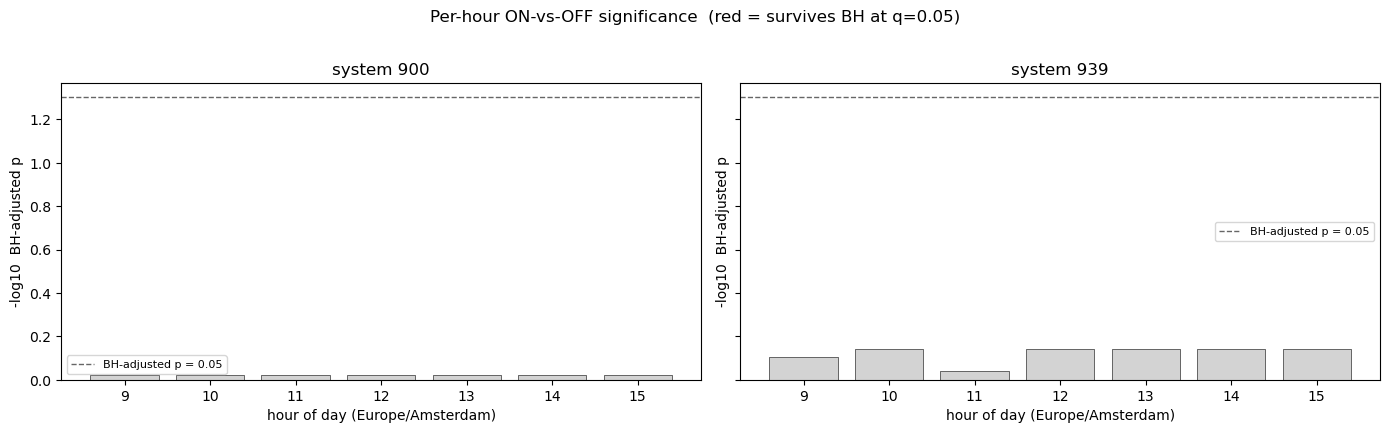

In [13]:
from scipy import stats
from scipy.stats import false_discovery_control

# Build the (date, system, hour) -> count table
tracks_with_hour = tracks[tracks["hive_exit_v3"] == True].copy()
tracks_with_hour["hour"] = tracks_with_hour["ts"].dt.hour
tracks_with_hour["date"] = tracks_with_hour["ts"].dt.date

hourly = (tracks_with_hour
          .groupby(["date", "system_id", "hour"]).size()
          .rename("n_v3").reset_index())
hourly["date"]      = pd.to_datetime(hourly["date"])
hourly["condition"] = hourly["date"].apply(condition_for)

ACTIVE_HOURS = list(range(9, 16))  # 09:00 .. 15:59 (active foraging window)

fig, axes = plt.subplots(1, len(systems), figsize=(7 * len(systems), 4.2),
                         sharey=True, squeeze=False)

for ax, sid in zip(axes[0], systems):
    pvals, on_med, off_med = [], [], []
    for h in ACTIVE_HOURS:
        sub = hourly[(hourly["system_id"] == sid) & (hourly["hour"] == h)]
        # Fill in missing (date, system, hour) zeros: a date with no exits at hour h
        # should count as 0, not be silently dropped.
        all_dates = daily.loc[daily["system_id"] == sid, "date"]
        all_dates = pd.to_datetime(all_dates)
        full = pd.DataFrame({"date": all_dates})
        full["condition"] = full["date"].apply(condition_for)
        full = full.merge(sub[["date", "n_v3"]], on="date", how="left").fillna(0)

        on  = full.loc[full["condition"] == "ON",  "n_v3"]
        off = full.loc[full["condition"] == "OFF", "n_v3"]
        if len(on) and len(off):
            try:
                p = stats.mannwhitneyu(on, off, alternative="two-sided").pvalue
            except ValueError:
                p = 1.0
        else:
            p = 1.0
        pvals.append(p)
        on_med.append(on.median()); off_med.append(off.median())

    pvals = np.asarray(pvals)
    p_adj = false_discovery_control(pvals, method="bh")

    # bar of -log10 p_adj
    bars = ax.bar(ACTIVE_HOURS, -np.log10(np.clip(p_adj, 1e-3, 1)),
                  color=["tab:red" if p < 0.05 else "lightgrey" for p in p_adj],
                  edgecolor="black", linewidth=0.4)
    ax.axhline(-np.log10(0.05), color="black", ls="--", lw=1, alpha=0.6,
               label="BH-adjusted p = 0.05")
    ax.set_xticks(ACTIVE_HOURS)
    ax.set_xlabel("hour of day (Europe/Amsterdam)")
    ax.set_ylabel("-log10  BH-adjusted p")
    ax.set_title(f"system {sid}")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)

    # Annotate: print the table for this system
    print(f"\nsys {sid} - hour-by-hour ON-vs-OFF:")
    print(f"  {'hour':>4s} {'ON med':>8s} {'OFF med':>9s} {'p (raw)':>9s} {'p (BH)':>9s}")
    for h, om, fm, p, pa in zip(ACTIVE_HOURS, on_med, off_med, pvals, p_adj):
        flag = "  *" if pa < 0.05 else ""
        print(f"  {h:>4d} {om:>8.1f} {fm:>9.1f} {p:>9.3f} {pa:>9.3f}{flag}")

fig.suptitle("Per-hour ON-vs-OFF significance  (red = survives BH at q=0.05)",
             y=1.02)
plt.tight_layout()
plt.show()


# Section G - Behavioural anchors

Three per-(date, system) summaries that adapt to weather-driven shifts in the daily curve, instead of pinning a clock-time:

- **`first_exit_hour`** - hour of the first v3 exit. Sensitive to "activation" effects.
- **`peak_hour`** - hour with the most v3 exits. Sensitive to *when* foraging is concentrated.
- **`active_hours`** - count of hours with > 5 v3 exits. Sensitive to the *length* of the active window.

If a cold morning shifts the whole curve later, the *peak hour* shifts with it — so comparing peak hours between conditions is comparing like-for-like behaviour rather than like-for-like clock-time.


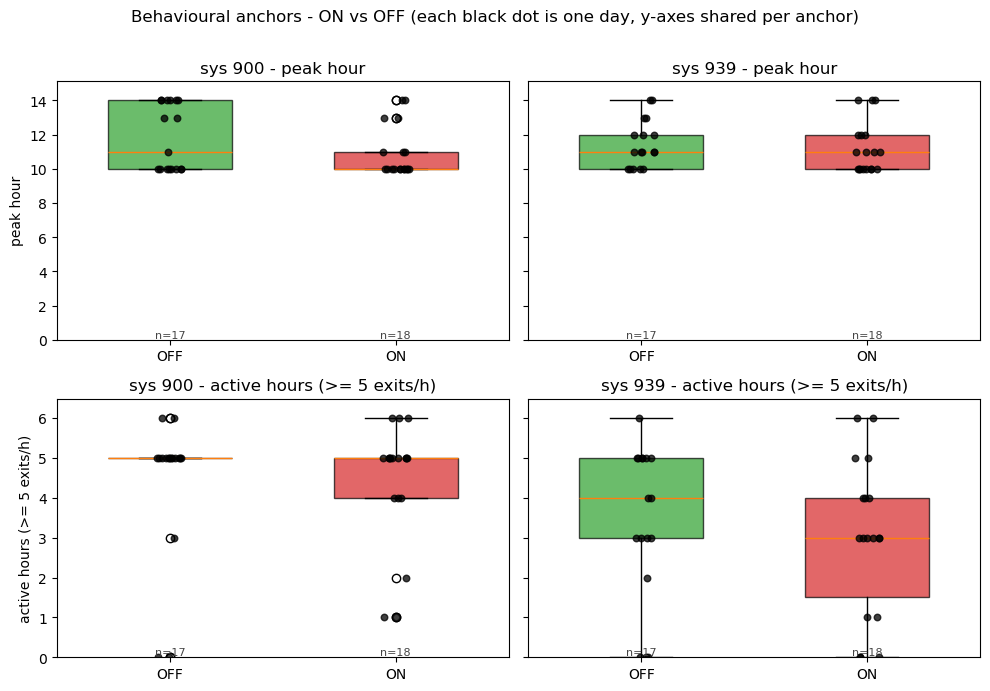


anchor                     sys   ON med   OFF med   p (MWU)
  peak hour                900     10.0      11.0     0.204
  peak hour                939     11.0      11.0     0.492
  active hours (>= 5 exits/h)  900      5.0       5.0     0.751
  active hours (>= 5 exits/h)  939      3.0       4.0     0.500


In [14]:
ACTIVITY_THRESHOLD = 5  # exits/hour to count as "active"
C_ORDER  = ["OFF", "ON"]

# Build per-(date, system) anchors
anchors_rows = []
for (d, sid), grp in tracks_with_hour.groupby(["date", "system_id"]):
    counts = grp.groupby("hour").size()
    if counts.empty:
        continue
    anchors_rows.append({
        "date":             pd.Timestamp(d),
        "system_id":        sid,
        "peak_hour":        int(counts.idxmax()),
        "peak_count":       int(counts.max()),
        "active_hours":     int((counts >= ACTIVITY_THRESHOLD).sum()),
    })
anchors = pd.DataFrame(anchors_rows)
anchors["condition"] = anchors["date"].apply(condition_for)

ANCHORS = [("peak_hour",       "peak hour"),
           ("active_hours",    f"active hours (>= {ACTIVITY_THRESHOLD} exits/h)")]

contrast_anchors = anchors[anchors["condition"].isin(["OFF", "ON"])]
if contrast_anchors.empty:
    print("No ON/OFF anchor data yet.")
else:
    fig, axes = plt.subplots(len(ANCHORS), len(systems),
                             figsize=(5 * len(systems), 3.4 * len(ANCHORS)),
                             sharey="row",  # same y-axis across systems per anchor
                             squeeze=False)
    for r, (col, label) in enumerate(ANCHORS):
        # global max so the shared y starts at 0 and reaches the larger system
        ymax = contrast_anchors[col].max()
        for c_ax, sid in enumerate(systems):
            ax = axes[r, c_ax]
            sub = contrast_anchors[contrast_anchors["system_id"] == sid]
            data = [sub.loc[sub["condition"] == c, col].dropna() for c in ORDER]
            bp = ax.boxplot(data, tick_labels=ORDER, patch_artist=True, widths=0.55)
            groups = [sub.loc[sub["condition"] == k, col].dropna().values
                  for k in C_ORDER]
            for patch, c in zip(bp["boxes"], ORDER):
                patch.set_facecolor(COLORS[c]); patch.set_alpha(0.7)
            for i, dvals in enumerate(data):
                ax.scatter(np.full(len(dvals), i + 1) + np.random.uniform(-0.06, 0.06, len(dvals)),
                           dvals, color="black", s=22, alpha=0.75, zorder=3)
            ax.set_title(f"sys {sid} - {label}")
            if c_ax == 0:
                ax.set_ylabel(label)
            ax.set_ylim(0, ymax * 1.08 if ymax > 0 else 1)
            for i, vals in enumerate(groups, start=1):
                if len(vals):
                    ax.text(i, ax.get_ylim()[0],
                            f"n={len(vals)}", ha="center", va="bottom",
                            fontsize=8, color="#444")
    fig.suptitle("Behavioural anchors - ON vs OFF (each black dot is one day, y-axes shared per anchor)",
                 y=1.01)
    plt.tight_layout()
    plt.show()

    # Stat tests
    print(f"\n{'anchor':25s} {'sys':>4s} {'ON med':>8s} {'OFF med':>9s} {'p (MWU)':>9s}")
    for col, label in ANCHORS:
        for sid in systems:
            sub = contrast_anchors[contrast_anchors["system_id"] == sid]
            on  = sub.loc[sub["condition"] == "ON",  col].dropna()
            off = sub.loc[sub["condition"] == "OFF", col].dropna()
            if len(on) and len(off):
                p = stats.mannwhitneyu(on, off, alternative="two-sided").pvalue
                print(f"  {label:23s} {sid:>4d} {on.median():>8.1f} {off.median():>9.1f} {p:>9.3f}")


In [16]:
print(anchors[anchors['condition'].isin(['ON','OFF'])].groupby(['date']).size().reset_index().to_string())

         date  0
0  2026-04-23  2
1  2026-04-24  2
2  2026-04-25  2
3  2026-04-26  2
4  2026-04-27  2
5  2026-04-28  2
6  2026-04-29  2
7  2026-04-30  2
8  2026-05-01  2
9  2026-05-02  2
10 2026-05-03  2
11 2026-05-04  2
12 2026-05-05  2
13 2026-05-06  2
14 2026-05-07  2
15 2026-05-08  2
16 2026-05-09  2
17 2026-05-10  2
18 2026-05-11  2
19 2026-05-12  2
20 2026-05-13  2
21 2026-05-14  2
22 2026-05-15  2
23 2026-05-16  2
24 2026-05-17  2
25 2026-05-18  2
26 2026-05-19  2
27 2026-05-20  2
28 2026-05-21  2
29 2026-05-22  2
30 2026-05-23  2
31 2026-05-24  2
32 2026-05-25  2
33 2026-05-27  2
34 2026-05-28  2


# Section H - Vertical behaviour at frame edge

Section D analysed the *horizontal* heading at the moment the bee enters/leaves the camera FOV. This section adds the *vertical* coordinate (`z`) at those same endpoints — the **height at which a bee enters or leaves the field of view**.

PATS-C uses a downward-looking convention: the camera sits at z = 0, and `z` becomes more negative the further you go from the camera (typically toward the ground). The hive sits at z ≈ −1.2 m for sys 900 and z ≈ −1.05 m for sys 939, indicated by the dashed line in each histogram. A bee at z **closer to 0** (less negative) is flying *above* the hive — typical, since bees climb after exiting and descend before returning. Tracks dipping below the hive Z are usually near-ground or low-altitude flights.

Two questions:
1. **Distribution shape (per-track histogram).** Are bees entering/exiting at different heights when the transmitter is ON?
2. **Daily median (one number per (date, system)).** Robust to outlier tracks; appropriate for a 6 vs 6 day MWU.

If the transmitter disturbs vertical orientation, we'd expect the distributions to broaden (more variance), shift toward the ground (flying lower), or both.


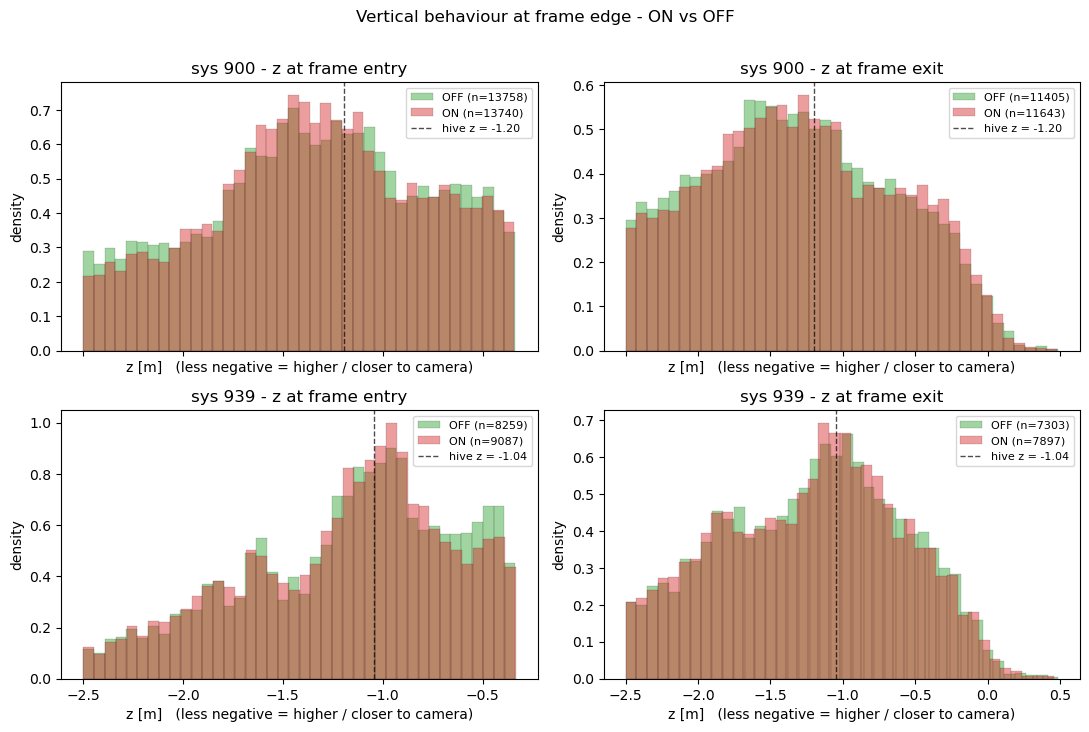

In [17]:
# Frame-edge entries/exits (hive endpoints already excluded in Section D)
frame_entries_z = geom[~geom["entry_at_hive"]].copy()
frame_exits_z   = geom[~geom["exit_at_hive"]].copy()

fig, axes = plt.subplots(len(systems), 2,
                         figsize=(11, 3.6 * len(systems)),
                         sharex="col", squeeze=False)
for r, sid in enumerate(systems):
    hive_z = HIVE_BY_SYSTEM[sid][2]
    for c_idx, (df, col, title) in enumerate([
        (frame_entries_z, "z_first", "z at frame entry"),
        (frame_exits_z,   "z_last",  "z at frame exit"),
    ]):
        ax = axes[r, c_idx]
        sub = df[df["system_id"] == sid]
        for cond, color in [("OFF", COLORS["OFF"]), ("ON", COLORS["ON"])]:
            vals = sub.loc[sub["condition"] == cond, col].dropna()
            if len(vals) == 0:
                continue
            # Clip to a sensible window so single-track outliers don't blow up the bins
            vals = vals[vals.between(-2.5, 0.5)]
            ax.hist(vals, bins=40, alpha=0.45, color=color, density=True,
                    label=f"{cond} (n={len(vals)})",
                    edgecolor="black", linewidth=0.2)
        ax.axvline(hive_z, color="black", ls="--", lw=1, alpha=0.7,
                   label=f"hive z = {hive_z:.2f}")
        ax.set_xlabel("z [m]   (less negative = higher / closer to camera)")
        ax.set_ylabel("density")
        ax.set_title(f"sys {sid} - {title}")
        ax.legend(fontsize=8)
fig.suptitle("Vertical behaviour at frame edge - ON vs OFF", y=1.01)
plt.tight_layout()
plt.show()


## H.2 Daily median z at entry/exit — ON vs OFF

For each (date, system) the median z-coordinate of frame entries and frame exits. One dot per day. Sharey across the two cameras so magnitudes are directly comparable.


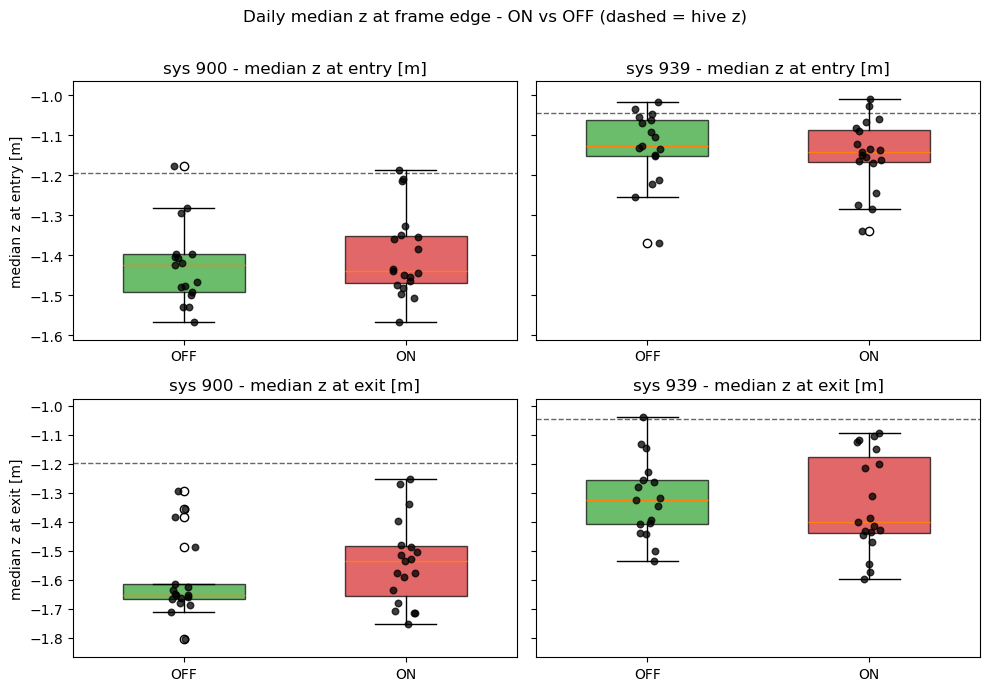


metric                        sys   ON med   OFF med   p (MWU)
  median z at entry [m]       900    -1.44     -1.42     0.466
  median z at entry [m]       939    -1.14     -1.13     0.375
  median z at exit [m]        900    -1.53     -1.65     0.205
  median z at exit [m]        939    -1.40     -1.32     0.704


In [18]:
# Build daily medians
def daily_z_table(df, col, name):
    out = (df.dropna(subset=[col])
             .groupby(["date", "system_id"])[col]
             .median()
             .reset_index(name=name))
    out["date"]      = pd.to_datetime(out["date"])
    out["condition"] = out["date"].apply(condition_for)
    return out

z_entry_daily = daily_z_table(frame_entries_z, "z_first", "z_entry_med")
z_exit_daily  = daily_z_table(frame_exits_z,   "z_last",  "z_exit_med")

VERT_METRICS = [(z_entry_daily, "z_entry_med", "median z at entry [m]"),
                (z_exit_daily,  "z_exit_med",  "median z at exit [m]")]

fig, axes = plt.subplots(len(VERT_METRICS), len(systems),
                         figsize=(5 * len(systems), 3.4 * len(VERT_METRICS)),
                         sharey="row", squeeze=False)
for r, (table, col, label) in enumerate(VERT_METRICS):
    contrast = table[table["condition"].isin(ORDER)]
    # Use min/max for ylim since z is negative
    if len(contrast):
        ymin, ymax = contrast[col].min(), contrast[col].max()
        pad = 0.08 * (ymax - ymin) if ymax > ymin else 0.05
    else:
        ymin, ymax, pad = -1.5, -0.5, 0.05
    for c_ax, sid in enumerate(systems):
        ax  = axes[r, c_ax]
        sub = contrast[contrast["system_id"] == sid]
        data = [sub.loc[sub["condition"] == c, col].dropna() for c in ORDER]
        bp = ax.boxplot(data, tick_labels=ORDER, patch_artist=True, widths=0.55)
        for patch, c in zip(bp["boxes"], ORDER):
            patch.set_facecolor(COLORS[c]); patch.set_alpha(0.7)
        for i, dvals in enumerate(data):
            ax.scatter(np.full(len(dvals), i + 1) + np.random.uniform(-0.06, 0.06, len(dvals)),
                       dvals, color="black", s=22, alpha=0.75, zorder=3)
        ax.axhline(HIVE_BY_SYSTEM[sid][2], color="black", ls="--", lw=1, alpha=0.6)
        ax.set_title(f"sys {sid} - {label}")
        if c_ax == 0:
            ax.set_ylabel(label)
        ax.set_ylim(ymin - pad, ymax + pad)  # shared y per row, NOT clamped to 0 (z is negative)
fig.suptitle("Daily median z at frame edge - ON vs OFF (dashed = hive z)",
             y=1.01)
plt.tight_layout()
plt.show()

# Stat tests
print(f"\n{'metric':28s} {'sys':>4s} {'ON med':>8s} {'OFF med':>9s} {'p (MWU)':>9s}")
for table, col, label in VERT_METRICS:
    contrast = table[table["condition"].isin(ORDER)]
    for sid in systems:
        sub = contrast[contrast["system_id"] == sid]
        on  = sub.loc[sub["condition"] == "ON",  col].dropna()
        off = sub.loc[sub["condition"] == "OFF", col].dropna()
        if len(on) and len(off):
            p = stats.mannwhitneyu(on, off, alternative="two-sided").pvalue
            print(f"  {label:26s} {sid:>4d} {on.median():>8.2f} {off.median():>9.2f} {p:>9.3f}")


# Section I - Inter-foraging interval (IFI)

The **inter-foraging interval** is the time gap between two consecutive foraging trips. In the bee literature, this is normally a *per-bee* metric — but PATS-C doesn't track bee identity, so we can't measure that directly. What we *can* measure is the **population-level IFI**: time between consecutive `hive_exit_v3` events at the hive entrance, ignoring identity.

This is a coarser indicator: a long population-level IFI just means few bees are leaving, not necessarily that any individual bee has a long inter-trip interval. But it's still informative — when colony-level outbound rate slows, IFI grows. And because it's measured directly from exit timestamps, it doesn't depend on the noisy greedy exit→return pairing.

Per (date, system):
- Sort the v3 exits by time and take the diff of consecutive `ts` values
- Take the **median** of those diffs as the day's IFI

Then ON vs OFF boxplots and MWU. We also plot the *distribution* of all IFI values (clipped at 30 min) to see whether the change is in the typical gap or in the long tail.


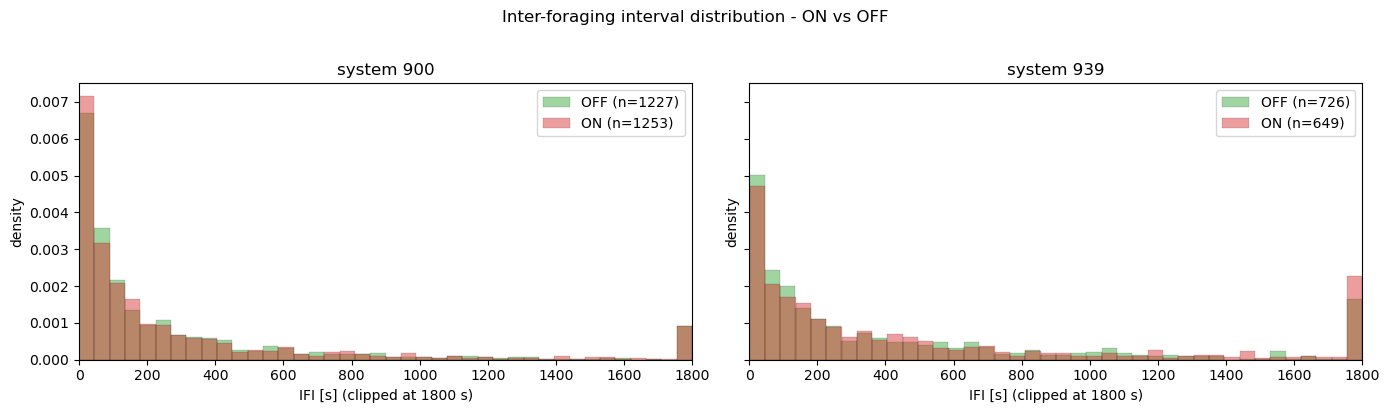

In [19]:
# Build IFI from per-track exit timestamps
exits = tracks[(tracks["hive_exit_v3"] == True) & tracks["ts"].notna()].copy()
exits = exits.sort_values(["system_id", "date", "ts"]).reset_index(drop=True)
exits["ifi_s"] = exits.groupby(["system_id", "date"])["ts"].diff().dt.total_seconds()
exits["condition"] = exits["date"].apply(condition_for)

# Distribution histogram (clipped at 30 min so the long tail doesn't blow out the x-axis)
IFI_CLIP_S = 1800
fig, axes = plt.subplots(1, len(systems), figsize=(7 * len(systems), 4),
                         sharey=True, squeeze=False)
for ax, sid in zip(axes[0], systems):
    sub = exits[(exits["system_id"] == sid) &
                exits["condition"].isin(ORDER) &
                exits["ifi_s"].notna()]
    for cond, color in [("OFF", COLORS["OFF"]), ("ON", COLORS["ON"])]:
        vals = sub.loc[sub["condition"] == cond, "ifi_s"].clip(upper=IFI_CLIP_S)
        if len(vals) == 0:
            continue
        ax.hist(vals, bins=40, alpha=0.45, color=color, density=True,
                label=f"{cond} (n={len(vals)})", edgecolor="black", linewidth=0.2)
    ax.set_xlabel(f"IFI [s] (clipped at {IFI_CLIP_S} s)")
    ax.set_ylabel("density")
    ax.set_title(f"system {sid}")
    ax.set_xlim(0, IFI_CLIP_S)
    ax.legend()
fig.suptitle("Inter-foraging interval distribution - ON vs OFF", y=1.02)
plt.tight_layout()
plt.show()


## I.2 Daily median IFI — ON vs OFF

One number per (date, system): the median time between successive hive exits that day. Shorter IFI = more frequent foraging.


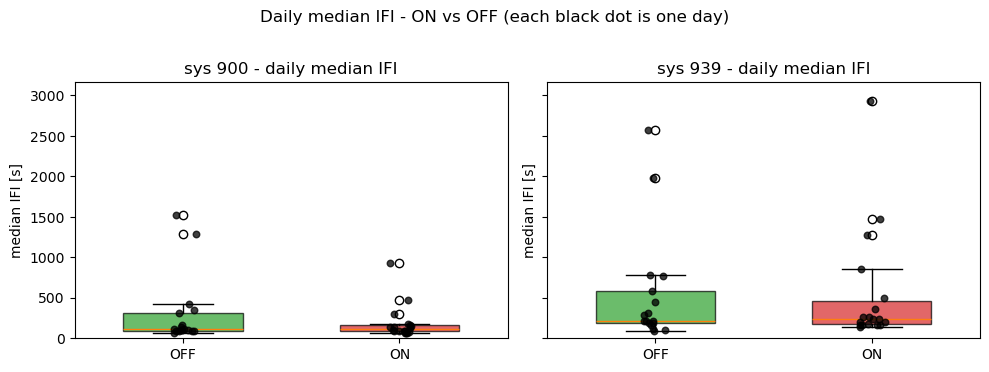


metric                     sys     ON med     OFF med   p (MWU)
  median IFI [s]           900      114.5       109.5     0.391
  median IFI [s]           939      233.8       216.0     0.987


In [20]:
# Daily median IFI per (date, system)
daily_ifi = (exits.dropna(subset=["ifi_s"])
                  .groupby(["date", "system_id"])["ifi_s"]
                  .median()
                  .reset_index(name="median_ifi_s"))
daily_ifi["condition"] = daily_ifi["date"].apply(condition_for)

contrast_ifi = daily_ifi[daily_ifi["condition"].isin(ORDER)]
if contrast_ifi.empty:
    print("No ON/OFF IFI data yet.")
else:
    fig, axes = plt.subplots(1, len(systems), figsize=(5 * len(systems), 3.6),
                             sharey=True, squeeze=False)
    ymax = contrast_ifi["median_ifi_s"].max()
    for ax, sid in zip(axes[0], systems):
        sub = contrast_ifi[contrast_ifi["system_id"] == sid]
        data = [sub.loc[sub["condition"] == c, "median_ifi_s"].dropna() for c in ORDER]
        bp = ax.boxplot(data, tick_labels=ORDER, patch_artist=True, widths=0.55)
        for patch, c in zip(bp["boxes"], ORDER):
            patch.set_facecolor(COLORS[c]); patch.set_alpha(0.7)
        for i, dvals in enumerate(data):
            ax.scatter(np.full(len(dvals), i + 1) + np.random.uniform(-0.06, 0.06, len(dvals)),
                       dvals, color="black", s=22, alpha=0.75, zorder=3)
        ax.set_title(f"sys {sid} - daily median IFI")
        ax.set_ylabel("median IFI [s]")
        ax.set_ylim(0, ymax * 1.08 if ymax > 0 else 1)
    fig.suptitle("Daily median IFI - ON vs OFF (each black dot is one day)", y=1.02)
    plt.tight_layout()
    plt.show()

    # Stat test
    print(f"\n{'metric':25s} {'sys':>4s} {'ON med':>10s} {'OFF med':>11s} {'p (MWU)':>9s}")
    for sid in systems:
        sub = contrast_ifi[contrast_ifi["system_id"] == sid]
        on  = sub.loc[sub["condition"] == "ON",  "median_ifi_s"].dropna()
        off = sub.loc[sub["condition"] == "OFF", "median_ifi_s"].dropna()
        if len(on) and len(off):
            p = stats.mannwhitneyu(on, off, alternative="two-sided").pvalue
            print(f"  {'median IFI [s]':23s} {sid:>4d} {on.median():>10.1f} {off.median():>11.1f} {p:>9.3f}")


# Section J - Daily curve with temperature overlay

A contextual / overview panel: daily v3 exits with **daytime mean air temperature** overlaid on a twin y-axis, plotted separately for ON and OFF days.

The point isn't statistical — it's to *see* whether the activity curve tracks temperature rather than the ON/OFF schedule.  If ON-day exits and OFF-day exits both rise and fall with temperature in the same way, the visual story is "weather drives this, not the transmitter".

KNMI hourly data is loaded from `../../../data/wind_data_04-19_to_05-06.txt` (same source `weather_join.ipynb` uses).  If the file is missing the section is skipped with a clear note.


In [21]:
# --- J.1 Load KNMI hourly weather and build daily mean T -----------------
import re as _re
_wind_dir = Path("../../../data")
def _wind_endkey(p):
    m = _re.findall(r"to_(\d{2})-(\d{2})", p.name)
    return (int(m[0][0]), int(m[0][1])) if m else (0, 0)
_wind_files = sorted(_wind_dir.glob("wind_data_*_to_*.txt"), key=_wind_endkey)
WIND_FILE = _wind_files[-1] if _wind_files else _wind_dir / "wind_data_missing.txt"
print(f"Using wind file: {{WIND_FILE.name}}")

if not WIND_FILE.exists():
    print(f"KNMI file not found at {WIND_FILE.resolve()} - skipping Section J.")
    daily_T = None
else:
    KNMI_COLS = ["STN","YYYYMMDD","HH","DD","FH","FF","FX","T","T10N","TD",
                 "SQ","Q","DR","RH","P","VV","N","U","WW","IX","M","R","S","O","Y"]
    raw = pd.read_csv(WIND_FILE, comment="#", names=KNMI_COLS,
                      skipinitialspace=True, na_values=["", " "])
    raw["ts_utc"]   = (pd.to_datetime(raw["YYYYMMDD"].astype(int), format="%Y%m%d")
                       + pd.to_timedelta(raw["HH"].astype(int) - 1, unit="h"))
    raw["ts_utc"]   = raw["ts_utc"].dt.tz_localize("UTC")
    raw["ts_local"] = raw["ts_utc"].dt.tz_convert("Europe/Amsterdam")
    raw["date"]     = raw["ts_local"].dt.date
    raw["hour"]     = raw["ts_local"].dt.hour
    raw["T_C"]      = raw["T"] / 10.0

    DAY_HOURS = (8, 18)
    daytime = raw[raw["hour"].between(DAY_HOURS[0], DAY_HOURS[1] - 1)]
    daily_T = (daytime.groupby("date")["T_C"].mean()
                       .rename("T_mean_day")
                       .reset_index())
    daily_T["date"] = pd.to_datetime(daily_T["date"])
    print(f"Loaded {len(daily_T)} dates of daytime mean T "
          f"({daily_T['T_mean_day'].min():.1f} - {daily_T['T_mean_day'].max():.1f} degC)")


Using wind file: {WIND_FILE.name}
Loaded 47 dates of daytime mean T (9.3 - 24.7 degC)


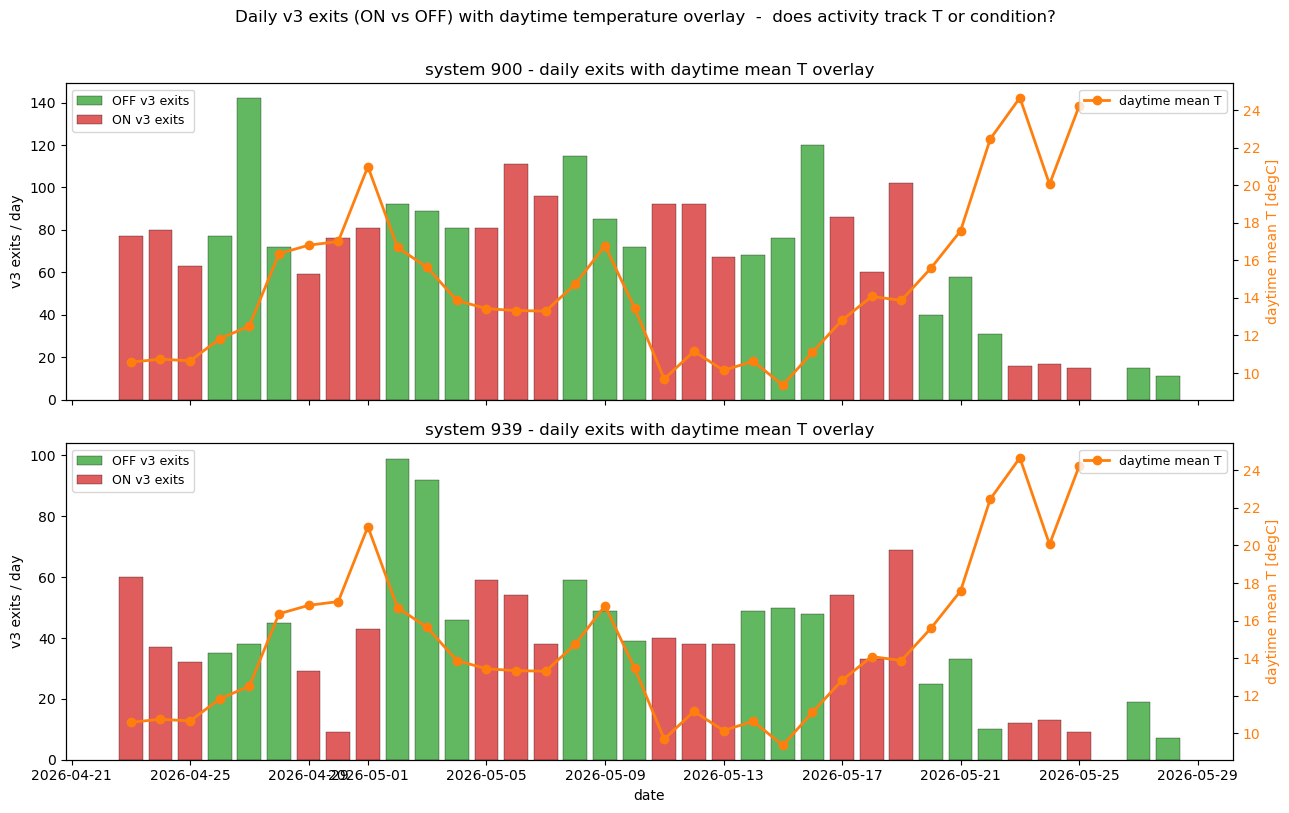


system    rho(n_v3 vs T)         p     n
   900              -0.397     0.022    33
   939              -0.369     0.034    33


In [22]:
# --- J.2 Daily curve, ON vs OFF, with temperature overlay ----------------
# Re-uses the same per-(date, system) v3-exit table as Section A but limits
# to ON / OFF days only and overlays daytime mean T on a twin y-axis.
if daily_T is None:
    print("Skipping J.2 - no temperature data.")
else:
    daily_with_T = daily.copy()
    daily_with_T["date"] = pd.to_datetime(daily_with_T["date"])
    daily_with_T = daily_with_T.merge(daily_T, on="date", how="left")
    daily_with_T = daily_with_T[daily_with_T["condition"].isin(ORDER)]

    fig, axes = plt.subplots(len(systems), 1,
                              figsize=(13, 4 * len(systems)),
                              sharex=True, squeeze=False)
    for ax, sid in zip(axes[:, 0], systems):
        sub = daily_with_T[daily_with_T["system_id"] == sid].sort_values("date")
        # Plot ON and OFF as separate coloured bars on the same axes
        for cond in ORDER:
            s = sub[sub["condition"] == cond]
            ax.bar(s["date"], s["n_v3"], width=0.8,
                   color=COLORS[cond], alpha=0.75,
                   label=f"{cond} v3 exits", edgecolor="black", linewidth=0.3)
        ax.set_ylabel("v3 exits / day")
        ax.set_title(f"system {sid} - daily exits with daytime mean T overlay")
        ax.legend(loc="upper left", fontsize=9)
        ax.set_ylim(bottom=0)

        ax2 = ax.twinx()
        ax2.plot(sub["date"], sub["T_mean_day"], color="tab:orange",
                 marker="o", lw=2, label="daytime mean T")
        ax2.set_ylabel("daytime mean T [degC]", color="tab:orange")
        ax2.tick_params(axis="y", labelcolor="tab:orange")
        ax2.legend(loc="upper right", fontsize=9)

    axes[-1, 0].set_xlabel("date")
    fig.suptitle("Daily v3 exits (ON vs OFF) with daytime temperature overlay  -  "
                 "does activity track T or condition?", y=1.01)
    plt.tight_layout()
    plt.show()

    # Quick sanity number: Spearman correlation between n_v3 and daytime T per system
    from scipy import stats as _stats
    print(f"\n{'system':>6s}  {'rho(n_v3 vs T)':>16s}  {'p':>8s}  {'n':>4s}")
    for sid in systems:
        s = daily_with_T[daily_with_T["system_id"] == sid].dropna(subset=["n_v3", "T_mean_day"])
        if len(s) >= 3:
            rho, p = _stats.spearmanr(s["n_v3"], s["T_mean_day"])
            print(f"  {sid:>4d}    {rho:>16.3f}  {p:>8.3f}  {len(s):>4d}")


# Section K - Indicator dashboard (ON vs OFF)

Five Tier-1 indicators rolled up into a single dashboard, all at the **per-(date, system)** level so each box-plot dot is one day.  Indicators:

- `exit_return_count` - `n_v3 + n_returns` per day (overall activity).
- `ifi_cv` - coefficient of variation of inter-foraging interval (regularity of foraging).
- `path_tortuosity` - daily *median* track tortuosity (navigation efficiency).
- `re_ratio` - returns-to-exits ratio (`re_ratio_v3` from `daily_summary.csv`).
- `vertical_behaviour` - daily median z at frame entry (signed; less negative = higher in FOV).

For each indicator: side-by-side boxplots ON vs OFF for both systems on one figure with **shared y-axis per indicator**, then Mann-Whitney U with BH correction across the five indicators (per system).  We report U, raw p, BH-adjusted p, and the rank-biserial correlation r as the effect size.  **Any indicator with |r| > 0.3 is flagged as "directional signal"** even if it doesn't survive p < 0.05.


In [23]:
# --- K.1 Build the per-(date, system) indicator table --------------------
# exit_return_count, re_ratio: from daily
# path_tortuosity:             daily median tortuosity from tracks
# ifi_cv:                      stdev/mean of IFI from `exits` (built in I.1)
# vertical_behaviour:          z_entry_med from H.2 (z_entry_daily)

# 1) exit_return_count + re_ratio per day
ind_base = daily[["date", "system_id", "n_v3", "n_returns", "re_ratio_v3", "condition"]].copy()
ind_base["date"] = pd.to_datetime(ind_base["date"])
ind_base["exit_return_count"] = ind_base["n_v3"].fillna(0) + ind_base["n_returns"].fillna(0)
ind_base = ind_base.rename(columns={"re_ratio_v3": "re_ratio"})

# 2) path_tortuosity per day (median over tracks)
tort_daily = (tracks.dropna(subset=["tortuosity"])
                    .groupby(["date", "system_id"])["tortuosity"]
                    .median()
                    .reset_index(name="path_tortuosity"))
tort_daily["date"] = pd.to_datetime(tort_daily["date"])

# 3) ifi_cv per day (CV = std / mean over within-day IFIs)
ifi_per_day = (exits.dropna(subset=["ifi_s"])
                     .groupby(["date", "system_id"])["ifi_s"]
                     .agg(["mean", "std", "count"])
                     .reset_index())
ifi_per_day["date"] = pd.to_datetime(ifi_per_day["date"])
ifi_per_day["ifi_cv"] = np.where(
    (ifi_per_day["mean"] > 0) & (ifi_per_day["count"] >= 2),
    ifi_per_day["std"] / ifi_per_day["mean"],
    np.nan,
)

# 4) vertical_behaviour: re-use z_entry_med from Section H.2
vert_daily = z_entry_daily.rename(columns={"z_entry_med": "vertical_behaviour"})[
    ["date", "system_id", "vertical_behaviour"]]
vert_daily["date"] = pd.to_datetime(vert_daily["date"])

# Merge everything onto ind_base
indicator_table = (ind_base
                   .merge(tort_daily, on=["date", "system_id"], how="left")
                   .merge(ifi_per_day[["date", "system_id", "ifi_cv"]],
                          on=["date", "system_id"], how="left")
                   .merge(vert_daily, on=["date", "system_id"], how="left"))

print("Indicator table preview (last 5 rows):")
cols = ["date", "system_id", "condition", "exit_return_count", "ifi_cv",
        "path_tortuosity", "re_ratio", "vertical_behaviour"]
print(indicator_table[cols].tail().to_string(index=False))
print(f"\nrows: {len(indicator_table)}  (per (date, system))")


Indicator table preview (last 5 rows):
      date  system_id condition  exit_return_count   ifi_cv  path_tortuosity  re_ratio  vertical_behaviour
2026-05-17        939        ON                 79 2.109513         2.295497  0.462963            -1.15019
2026-05-18        900        ON                115 2.749084         2.212512  0.916667            -1.35394
2026-05-18        939        ON                 86 1.339896         2.195224  1.606061            -1.15364
2026-05-19        900        ON                178 2.384517         2.264170  0.745098            -1.44335
2026-05-19        939        ON                132 2.514651         2.113351  0.913043            -1.24298

rows: 66  (per (date, system))


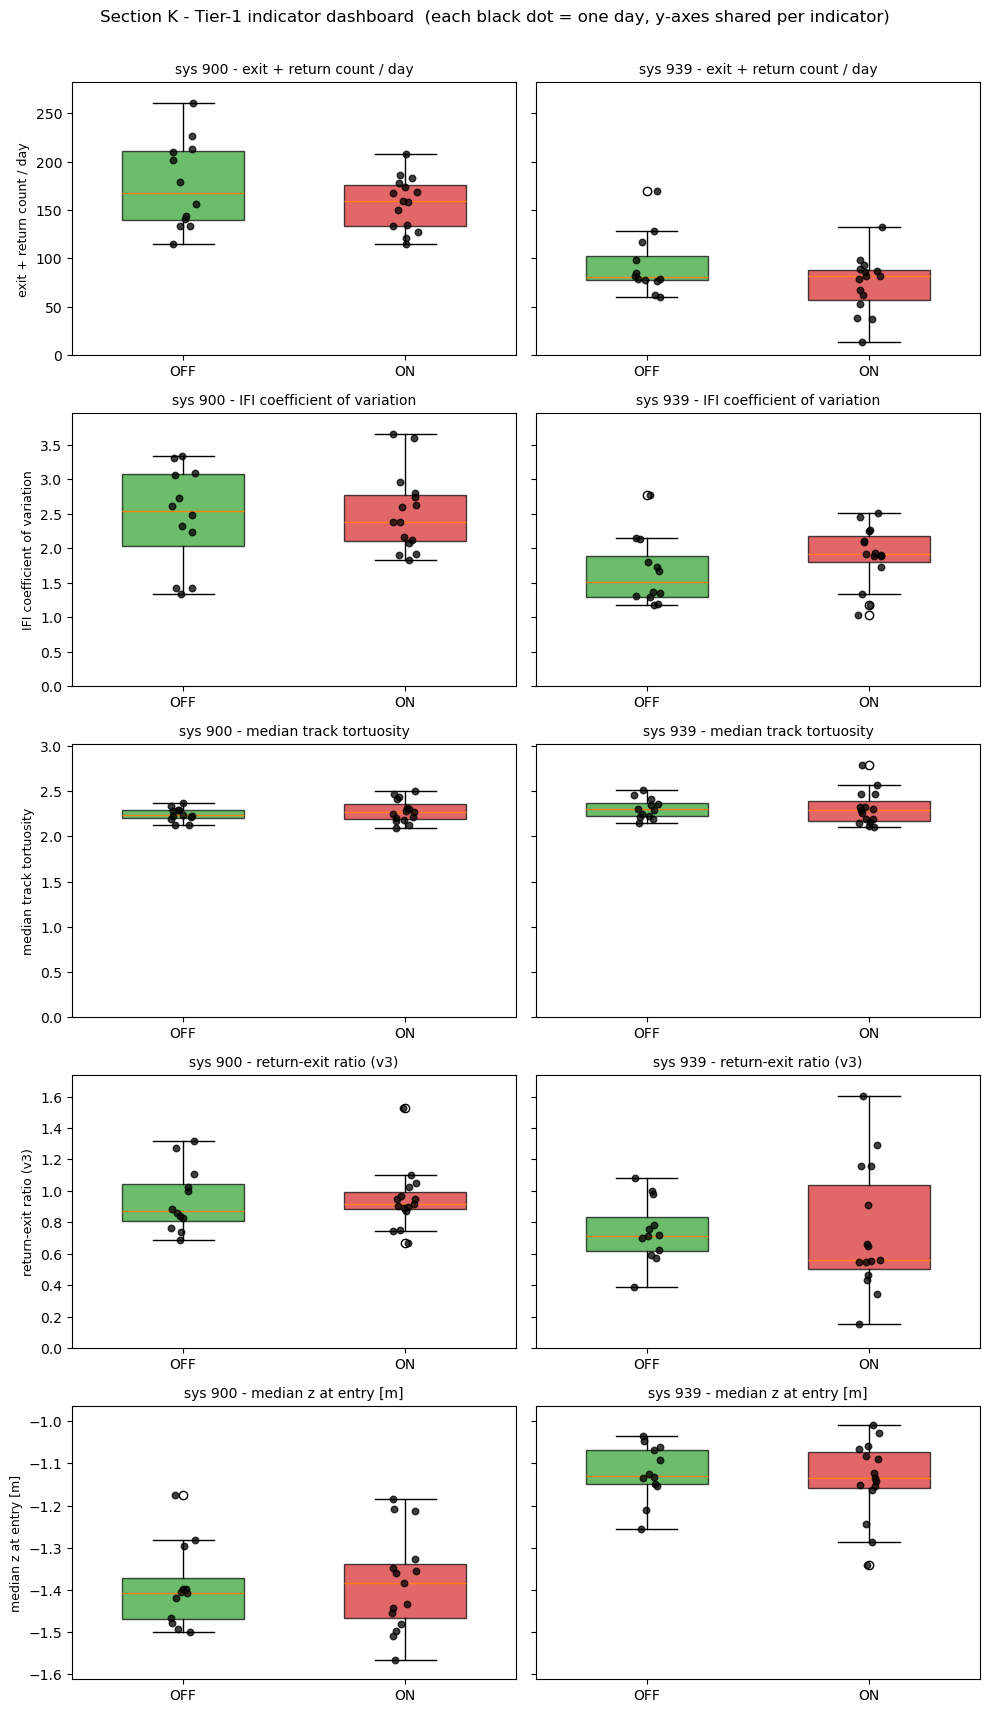

In [24]:
# --- K.2 Boxplots: 5 indicators, both systems, ON vs OFF -----------------
INDICATORS = [
    ("exit_return_count",  "exit + return count / day", False),  # clamp to 0
    ("ifi_cv",             "IFI coefficient of variation", False),
    ("path_tortuosity",    "median track tortuosity", False),
    ("re_ratio",           "return-exit ratio (v3)", False),
    ("vertical_behaviour", "median z at entry [m]", True),  # signed
]

contrast = indicator_table[indicator_table["condition"].isin(ORDER)].copy()

fig, axes = plt.subplots(len(INDICATORS), len(systems),
                          figsize=(5 * len(systems), 3.4 * len(INDICATORS)),
                          sharey="row", squeeze=False)
for r, (col, label, signed) in enumerate(INDICATORS):
    vals_all = contrast[col].dropna()
    if signed and len(vals_all):
        ymin, ymax = vals_all.min(), vals_all.max()
        pad = 0.08 * (ymax - ymin) if ymax > ymin else 0.05
        ylim = (ymin - pad, ymax + pad)
    else:
        ymax = vals_all.max() if len(vals_all) else 1
        ylim = (0, ymax * 1.08 if ymax > 0 else 1)
    for c_ax, sid in enumerate(systems):
        ax = axes[r, c_ax]
        sub = contrast[contrast["system_id"] == sid]
        data = [sub.loc[sub["condition"] == c, col].dropna() for c in ORDER]
        bp = ax.boxplot(data, tick_labels=ORDER, patch_artist=True, widths=0.55)
        for patch, c in zip(bp["boxes"], ORDER):
            patch.set_facecolor(COLORS[c]); patch.set_alpha(0.7)
        for i, dvals in enumerate(data):
            ax.scatter(np.full(len(dvals), i + 1) + np.random.uniform(-0.06, 0.06, len(dvals)),
                       dvals, color="black", s=22, alpha=0.75, zorder=3)
        ax.set_title(f"sys {sid} - {label}", fontsize=10)
        if c_ax == 0:
            ax.set_ylabel(label, fontsize=9)
        ax.set_ylim(*ylim)
fig.suptitle("Section K - Tier-1 indicator dashboard  (each black dot = one day, y-axes shared per indicator)",
             y=1.005)
plt.tight_layout()
plt.show()


In [25]:
# --- K.3 MWU + BH + rank-biserial r per (system, indicator) --------------
from scipy.stats import false_discovery_control, mannwhitneyu

def rank_biserial(on_vals, off_vals):
    """Two-sided rank-biserial correlation derived from Mann-Whitney U.

    r = 1 - 2U / (n1 * n2),  using U = U(off, on); positive r means
    OFF tends to have higher ranks than ON.  We report sign aligned to
    "ON higher than OFF" by negating, so positive r => ON > OFF.
    """
    n1, n2 = len(on_vals), len(off_vals)
    if n1 == 0 or n2 == 0:
        return float("nan")
    U_on = mannwhitneyu(on_vals, off_vals, alternative="two-sided").statistic
    return float(2 * U_on / (n1 * n2) - 1)

rows = []
for sid in systems:
    sub = contrast[contrast["system_id"] == sid]
    pvals_sys, summary_sys = [], []
    for col, label, _ in INDICATORS:
        on  = sub.loc[sub["condition"] == "ON",  col].dropna()
        off = sub.loc[sub["condition"] == "OFF", col].dropna()
        if len(on) and len(off):
            U, p = mannwhitneyu(on, off, alternative="two-sided")
            r    = rank_biserial(on, off)
        else:
            U, p, r = float("nan"), 1.0, float("nan")
        pvals_sys.append(p)
        summary_sys.append({"system_id": sid, "indicator": col,
                            "label": label,
                            "n_on": len(on), "n_off": len(off),
                            "on_med":  on.median()  if len(on)  else float("nan"),
                            "off_med": off.median() if len(off) else float("nan"),
                            "U": U, "p_raw": p, "r": r})
    p_adj = false_discovery_control(np.asarray(pvals_sys), method="bh")
    for entry, pa in zip(summary_sys, p_adj):
        entry["p_adj_BH"] = pa
        rows.append(entry)

dashboard = pd.DataFrame(rows)
dashboard["directional"] = dashboard["r"].abs() > 0.3
dashboard["sig_BH"]      = dashboard["p_adj_BH"] < 0.05

print("Section K - Tier-1 indicator dashboard (MWU + BH + rank-biserial r):")
print()
fmt = (f"{'sys':>4s} {'indicator':22s} {'on_med':>9s} {'off_med':>9s} "
       f"{'U':>7s} {'p_raw':>7s} {'p_BH':>7s} {'r':>7s}  flags")
print(fmt)
for _, row in dashboard.iterrows():
    flags = []
    if row["sig_BH"]:      flags.append("BH<0.05")
    if row["directional"]: flags.append(f"|r|>0.3 ({'ON>OFF' if row['r']>0 else 'ON<OFF'})")
    flag_str = "  " + ", ".join(flags) if flags else ""
    print(f"  {int(row['system_id']):>2d} {row['indicator']:22s} "
          f"{row['on_med']:>9.3f} {row['off_med']:>9.3f} "
          f"{row['U']:>7.0f} {row['p_raw']:>7.3f} "
          f"{row['p_adj_BH']:>7.3f} {row['r']:>+7.3f}{flag_str}")

print("\nDirectional flag = |r| > 0.3 (effect-size threshold, not p-based).")
print("BH adjustment is *within* each system across the 5 indicators.")


Section K - Tier-1 indicator dashboard (MWU + BH + rank-biserial r):

 sys indicator                 on_med   off_med       U   p_raw    p_BH       r  flags
  900 exit_return_count        159.000   167.500      70   0.329   0.981  -0.228
  900 ifi_cv                     2.386     2.547      89   0.981   0.981  -0.011
  900 path_tortuosity            2.264     2.234      99   0.678   0.981  +0.100
  900 re_ratio                   0.917     0.872      97   0.751   0.981  +0.078
  900 vertical_behaviour        -1.384    -1.406      93   0.903   0.981  +0.033
  939 exit_return_count         82.000    80.500      73   0.420   0.700  -0.189
  939 ifi_cv                     1.912     1.516     118   0.180   0.700  +0.311  |r|>0.3 (ON>OFF)
  939 path_tortuosity            2.295     2.297      83   0.751   0.751  -0.078
  939 re_ratio                   0.558     0.716      71   0.367   0.700  -0.211
  939 vertical_behaviour        -1.135    -1.129      82   0.714   0.751  -0.089

Directional fl

# Section L - Heading indicators (directional confusion)

If 5G affects the bees' navigation, an obvious place to look is the **distribution of heading angles**.  A more dispersed distribution (lower mean resultant length R) under ON would be evidence of directional confusion.

Three heading indicators, computed from `geom`:

- `exit_heading` - heading at the *first* moment a track is observed *leaving the hive* (`heading_entry_deg` for tracks where `entry_at_hive == True`).  Direction the bee chooses when it sets out.
- `frame_exit_heading` - heading as the bee leaves the FOV at the frame edge (Section D.3 already plots this — we re-use those data and add R/p).
- `frame_return_heading` - heading at frame entry for tracks that end at the hive (`heading_entry_deg` where `entry_at_hive == False AND exit_at_hive == True`).  Direction the bee comes home from.

For each: rose diagram **ON overlaid on OFF** per system, plus the mean resultant length R per condition.  We approximate Watson's U² for the ON-vs-OFF difference using a permutation test on R, since a clean Watson implementation isn't in scipy.


In [26]:
# --- L.1 Build per-track heading slices ----------------------------------
# exit_heading:        heading_entry_deg  where entry_at_hive == True
# frame_exit_heading:  heading_exit_deg   where exit_at_hive  == False  (already used in Section D.3)
# frame_return_heading:heading_entry_deg  where entry_at_hive == False AND exit_at_hive == True

heading_exit_hive   = geom[geom["entry_at_hive"] == True].rename(
    columns={"heading_entry_deg": "heading_deg"})[["date", "system_id", "condition", "heading_deg"]]

heading_frame_exit  = geom[geom["exit_at_hive"] == False].rename(
    columns={"heading_exit_deg": "heading_deg"})[["date", "system_id", "condition", "heading_deg"]]

heading_frame_ret   = geom[(geom["entry_at_hive"] == False) & (geom["exit_at_hive"] == True)].rename(
    columns={"heading_entry_deg": "heading_deg"})[["date", "system_id", "condition", "heading_deg"]]

HEADING_TABLES = [
    ("exit_heading",         "exit (hive -> frame)",         heading_exit_hive),
    ("frame_exit_heading",   "frame edge exit",              heading_frame_exit),
    ("frame_return_heading", "frame entry on return to hive", heading_frame_ret),
]

print("Heading slice sizes:")
for name, _, df in HEADING_TABLES:
    n_on  = ((df["condition"] == "ON")  & df["heading_deg"].notna()).sum()
    n_off = ((df["condition"] == "OFF") & df["heading_deg"].notna()).sum()
    print(f"  {name:25s}  ON={n_on:5d}  OFF={n_off:5d}")


Heading slice sizes:
  exit_heading               ON= 2342  OFF= 2349
  frame_exit_heading         ON=23461  OFF=22202
  frame_return_heading       ON= 2964  OFF= 3007


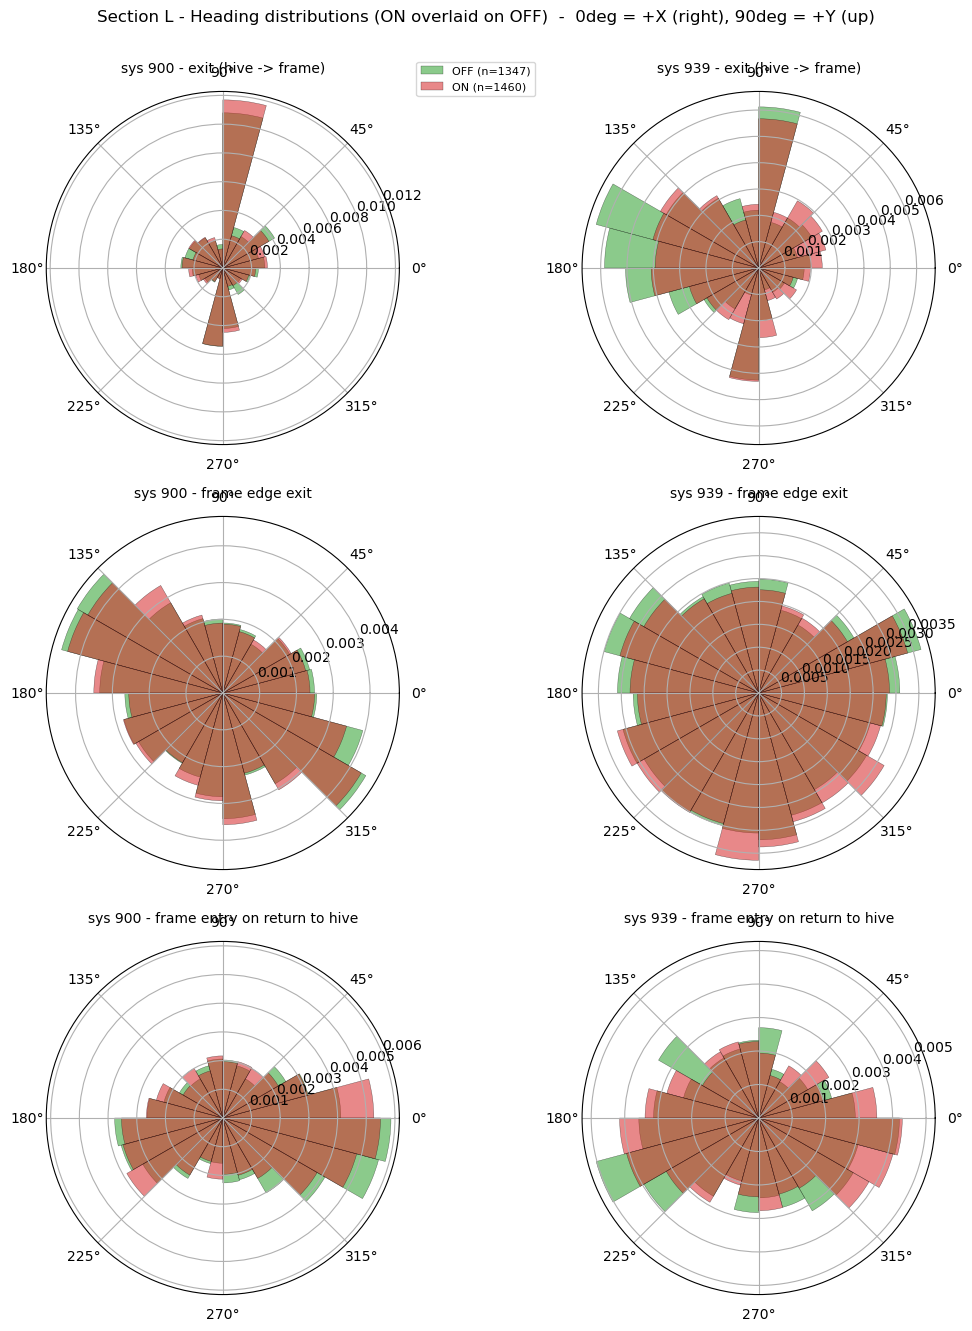

In [27]:
# --- L.2 Rose diagrams (ON overlaid on OFF) per (system, indicator) ------
def overlay_rose(ax, on_deg, off_deg, n_bins=24):
    bins = np.linspace(-180, 180, n_bins + 1)
    centers = np.deg2rad((bins[:-1] + bins[1:]) / 2)
    width   = np.deg2rad(np.diff(bins))
    if len(off_deg):
        c_off, _ = np.histogram(off_deg, bins=bins, density=True)
        ax.bar(centers, c_off, width=width, color=COLORS["OFF"],
               alpha=0.55, edgecolor="black", linewidth=0.3,
               label=f"OFF (n={len(off_deg)})")
    if len(on_deg):
        c_on, _ = np.histogram(on_deg, bins=bins, density=True)
        ax.bar(centers, c_on, width=width, color=COLORS["ON"],
               alpha=0.55, edgecolor="black", linewidth=0.3,
               label=f"ON (n={len(on_deg)})")
    ax.set_theta_zero_location("E"); ax.set_theta_direction(1)

fig, axes = plt.subplots(len(HEADING_TABLES), len(systems),
                         figsize=(5 * len(systems), 4.4 * len(HEADING_TABLES)),
                         subplot_kw=dict(polar=True), squeeze=False)
for r, (name, label, df) in enumerate(HEADING_TABLES):
    for c_ax, sid in enumerate(systems):
        ax = axes[r, c_ax]
        sub = df[df["system_id"] == sid]
        on_deg  = sub.loc[sub["condition"] == "ON",  "heading_deg"].dropna().values
        off_deg = sub.loc[sub["condition"] == "OFF", "heading_deg"].dropna().values
        overlay_rose(ax, on_deg, off_deg)
        ax.set_title(f"sys {sid} - {label}", fontsize=10, pad=14)
        if r == 0 and c_ax == 0:
            ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=8)
fig.suptitle("Section L - Heading distributions (ON overlaid on OFF)  -  0deg = +X (right), 90deg = +Y (up)",
             y=1.005)
plt.tight_layout()
plt.show()


In [28]:
# --- L.3 Mean resultant length R + permutation test for ON vs OFF --------
def R_of(deg_array):
    deg_array = np.asarray(deg_array, dtype=float)
    deg_array = deg_array[~np.isnan(deg_array)]
    if len(deg_array) == 0:
        return float("nan"), 0
    rad = np.deg2rad(deg_array)
    return float(np.abs(np.mean(np.exp(1j * rad)))), len(deg_array)

def perm_test_R_diff(on_deg, off_deg, n_perm=2000, seed=0):
    """Permutation test: |R_on - R_off| under the null that ON / OFF labels
    are exchangeable.  Returns (R_on, R_off, |R_on - R_off|, p).  p is a
    two-sided permutation p-value.
    """
    on_deg  = np.asarray(on_deg,  dtype=float)
    off_deg = np.asarray(off_deg, dtype=float)
    on_deg  = on_deg[~np.isnan(on_deg)]
    off_deg = off_deg[~np.isnan(off_deg)]
    if len(on_deg) == 0 or len(off_deg) == 0:
        return float("nan"), float("nan"), float("nan"), float("nan")
    R_on,  n_on  = R_of(on_deg)
    R_off, n_off = R_of(off_deg)
    obs = abs(R_on - R_off)
    pool = np.concatenate([on_deg, off_deg])
    rng = np.random.default_rng(seed)
    n1 = len(on_deg)
    count = 0
    for _ in range(n_perm):
        rng.shuffle(pool)
        a, b = pool[:n1], pool[n1:]
        ra = np.abs(np.mean(np.exp(1j * np.deg2rad(a))))
        rb = np.abs(np.mean(np.exp(1j * np.deg2rad(b))))
        if abs(ra - rb) >= obs:
            count += 1
    p = (count + 1) / (n_perm + 1)
    return R_on, R_off, obs, p

print("Section L - circular dispersion R (lower R = more dispersed = more 'confused')")
print(f"\n{'indicator':25s} {'sys':>4s} {'R_OFF':>7s} {'R_ON':>7s} "
      f"{'|dR|':>7s} {'p (perm)':>9s} {'n_off':>6s} {'n_on':>6s}")
for name, label, df in HEADING_TABLES:
    for sid in systems:
        sub = df[df["system_id"] == sid]
        on  = sub.loc[sub["condition"] == "ON",  "heading_deg"].dropna().values
        off = sub.loc[sub["condition"] == "OFF", "heading_deg"].dropna().values
        R_on, R_off, dR, p = perm_test_R_diff(on, off, n_perm=2000, seed=42)
        print(f"  {name:23s} {sid:>4d} {R_off:>7.3f} {R_on:>7.3f} "
              f"{dR:>7.3f} {p:>9.3f} {len(off):>6d} {len(on):>6d}")
print("\nInterpretation: a *significantly lower* R_ON than R_OFF (p < 0.05) "
      "would indicate ON-condition headings are more dispersed -- consistent with "
      "directional confusion.")


Section L - circular dispersion R (lower R = more dispersed = more 'confused')

indicator                  sys   R_OFF    R_ON    |dR|  p (perm)  n_off   n_on
  exit_heading             900   0.154   0.163   0.009     0.733   1347   1460
  exit_heading             939   0.293   0.163   0.129     0.000   1002    882
  frame_exit_heading       900   0.069   0.079   0.010     0.191  14053  14324
  frame_exit_heading       939   0.054   0.085   0.031     0.004   8149   9137
  frame_return_heading     900   0.147   0.121   0.027     0.261   1945   2001
  frame_return_heading     939   0.107   0.086   0.021     0.496   1062    963

Interpretation: a *significantly lower* R_ON than R_OFF (p < 0.05) would indicate ON-condition headings are more dispersed -- consistent with directional confusion.


# Section M - Accumulation analysis (Day 1 ON vs Day 3 ON)

If the transmitter has a **cumulative** effect, Day 3 of an ON block should show stronger suppression than Day 1.  We split ON days into:

- **Day 1 ON** - first calendar day of each ON block (i.e. days where `(date - CYCLE_ANCHOR) % CYCLE_LEN == 0`).
- **Day 3 ON** - third calendar day of each ON block (`% CYCLE_LEN == CYCLE_ON_DAYS - 1`, i.e. 2).

For each Tier-1 indicator (exit_return_count, ifi_cv, path_tortuosity, re_ratio) we compare Day-1 vs Day-3 with MWU per system.  Day 1 is plotted in a lighter shade of red, Day 3 in a darker shade.

This is severely underpowered (only 2 ON cycles in this dataset, so n=2 per group per system) — treat the result as exploratory.


In [29]:
# --- M.1 Tag each ON day with its position in the ON block ---------------
def on_block_day(d):
    """Return 1, 2, 3 for Day-1 / Day-2 / Day-3 of an ON block; NaN for OFF/BASELINE."""
    d = pd.Timestamp(d).normalize()
    if d < CYCLE_ANCHOR:
        return float("nan")
    pos = (d - CYCLE_ANCHOR).days % CYCLE_LEN
    if pos < CYCLE_ON_DAYS:
        return float(pos + 1)  # 1, 2, or 3
    return float("nan")

acc = indicator_table.copy()
acc["date"] = pd.to_datetime(acc["date"])
acc["on_day"] = acc["date"].apply(on_block_day)
acc_d1 = acc[acc["on_day"] == 1.0].assign(group="Day 1 ON")
acc_d3 = acc[acc["on_day"] == 3.0].assign(group="Day 3 ON")
acc_pair = pd.concat([acc_d1, acc_d3], ignore_index=True)

print("Day-1 vs Day-3 ON sample sizes per system:")
print(acc_pair.groupby(["system_id", "group"]).size().unstack(fill_value=0))


Day-1 vs Day-3 ON sample sizes per system:
group      Day 1 ON  Day 3 ON
system_id                    
900               5         5
939               5         5


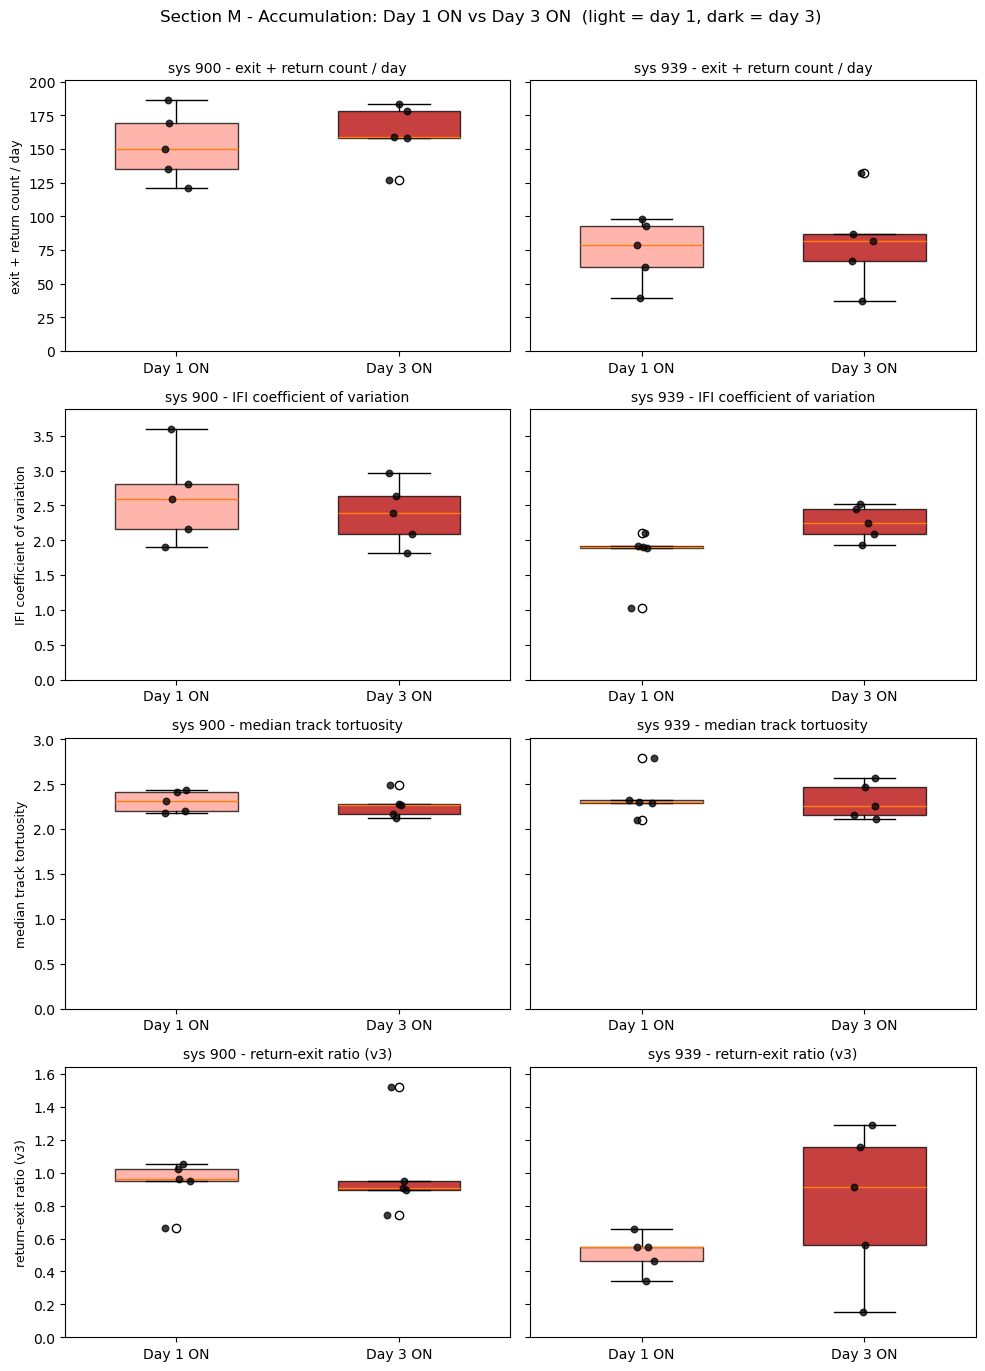


indicator               sys    D1 med    D3 med   p (MWU)  n_d1  n_d3
  exit_return_count     900   150.000   159.000     0.690     5     5
  exit_return_count     939    79.000    82.000     1.000     5     5
  ifi_cv                900     2.592     2.385     0.690     5     5
  ifi_cv                939     1.901     2.246     0.032     5     5
  path_tortuosity       900     2.312     2.264     0.548     5     5
  path_tortuosity       939     2.308     2.257     0.841     5     5
  re_ratio              900     0.965     0.906     0.690     5     5
  re_ratio              939     0.550     0.913     0.209     5     5

Note: with 2 ON cycles in this dataset, n is ~2 per group -- treat as exploratory.


In [30]:
# --- M.2 Boxplots Day 1 ON vs Day 3 ON, per system, per indicator --------
TIER1 = [
    ("exit_return_count", "exit + return count / day", False),
    ("ifi_cv",            "IFI coefficient of variation", False),
    ("path_tortuosity",   "median track tortuosity",  False),
    ("re_ratio",          "return-exit ratio (v3)",   False),
]
GROUP_ORDER  = ["Day 1 ON", "Day 3 ON"]
GROUP_COLORS = {"Day 1 ON": "#ff9c8f", "Day 3 ON": "#b30000"}  # light -> dark red

fig, axes = plt.subplots(len(TIER1), len(systems),
                          figsize=(5 * len(systems), 3.4 * len(TIER1)),
                          sharey="row", squeeze=False)
for r, (col, label, signed) in enumerate(TIER1):
    vals_all = acc_pair[col].dropna()
    if signed and len(vals_all):
        ymin, ymax = vals_all.min(), vals_all.max()
        pad = 0.08 * (ymax - ymin) if ymax > ymin else 0.05
        ylim = (ymin - pad, ymax + pad)
    else:
        ymax = vals_all.max() if len(vals_all) else 1
        ylim = (0, ymax * 1.08 if ymax > 0 else 1)
    for c_ax, sid in enumerate(systems):
        ax = axes[r, c_ax]
        sub = acc_pair[acc_pair["system_id"] == sid]
        data = [sub.loc[sub["group"] == g, col].dropna() for g in GROUP_ORDER]
        bp = ax.boxplot(data, tick_labels=GROUP_ORDER, patch_artist=True, widths=0.55)
        for patch, g in zip(bp["boxes"], GROUP_ORDER):
            patch.set_facecolor(GROUP_COLORS[g]); patch.set_alpha(0.75)
        for i, dvals in enumerate(data):
            ax.scatter(np.full(len(dvals), i + 1) + np.random.uniform(-0.06, 0.06, len(dvals)),
                       dvals, color="black", s=22, alpha=0.75, zorder=3)
        ax.set_title(f"sys {sid} - {label}", fontsize=10)
        if c_ax == 0:
            ax.set_ylabel(label, fontsize=9)
        ax.set_ylim(*ylim)
fig.suptitle("Section M - Accumulation: Day 1 ON vs Day 3 ON  (light = day 1, dark = day 3)",
             y=1.005)
plt.tight_layout()
plt.show()

# Stats
print(f"\n{'indicator':22s} {'sys':>4s} {'D1 med':>9s} {'D3 med':>9s} "
      f"{'p (MWU)':>9s} {'n_d1':>5s} {'n_d3':>5s}")
for col, label, _ in TIER1:
    for sid in systems:
        sub = acc_pair[acc_pair["system_id"] == sid]
        d1 = sub.loc[sub["group"] == "Day 1 ON", col].dropna()
        d3 = sub.loc[sub["group"] == "Day 3 ON", col].dropna()
        if len(d1) and len(d3):
            try:
                p = mannwhitneyu(d1, d3, alternative="two-sided").pvalue
            except ValueError:
                p = float("nan")
        else:
            p = float("nan")
        print(f"  {col:20s} {sid:>4d} {d1.median():>9.3f} {d3.median():>9.3f} "
              f"{p:>9.3f} {len(d1):>5d} {len(d3):>5d}")
print("\nNote: with 2 ON cycles in this dataset, n is ~2 per group -- treat as exploratory.")


# Section N - Sensitivity check (Day 3 OFF vs Day 1 ON)

If bees were already drifting (e.g. seasonally) **before** ON started, then ON-vs-OFF differences in Section K would be confounded with that drift, not caused by the transmitter.

This section compares the *last day of each OFF block* (Day 3 OFF) to the *first day of the immediately following ON block* (Day 1 ON).  These two days are 24 hours apart, so seasonal drift has barely had time to act.  If they're statistically indistinguishable for the Tier-1 indicators, the ON/OFF comparison in Sections C, K, and M survives the drift critique.

Same five Tier-1 indicators as Section K (we include `vertical_behaviour` here too — same five as the dashboard).


In [31]:
# --- N.1 Identify Day-3 OFF and the immediately following Day-1 ON --------
def off_block_day(d):
    """1, 2, 3 for Day-1 / Day-2 / Day-3 of an OFF block; NaN otherwise."""
    d = pd.Timestamp(d).normalize()
    if d < CYCLE_ANCHOR:
        return float("nan")
    pos = (d - CYCLE_ANCHOR).days % CYCLE_LEN
    if pos >= CYCLE_ON_DAYS:
        return float(pos - CYCLE_ON_DAYS + 1)  # 1, 2, or 3
    return float("nan")

sens = indicator_table.copy()
sens["date"]    = pd.to_datetime(sens["date"])
sens["on_day"]  = sens["date"].apply(on_block_day)
sens["off_day"] = sens["date"].apply(off_block_day)

sens_d3_off = sens[sens["off_day"] == 3.0].assign(group="Day 3 OFF")
sens_d1_on  = sens[sens["on_day"]  == 1.0].assign(group="Day 1 ON")
sens_pair = pd.concat([sens_d3_off, sens_d1_on], ignore_index=True)

print("Day-3 OFF vs Day-1 ON sample sizes per system:")
print(sens_pair.groupby(["system_id", "group"]).size().unstack(fill_value=0))


Day-3 OFF vs Day-1 ON sample sizes per system:
group      Day 1 ON  Day 3 OFF
system_id                     
900               5          4
939               5          4


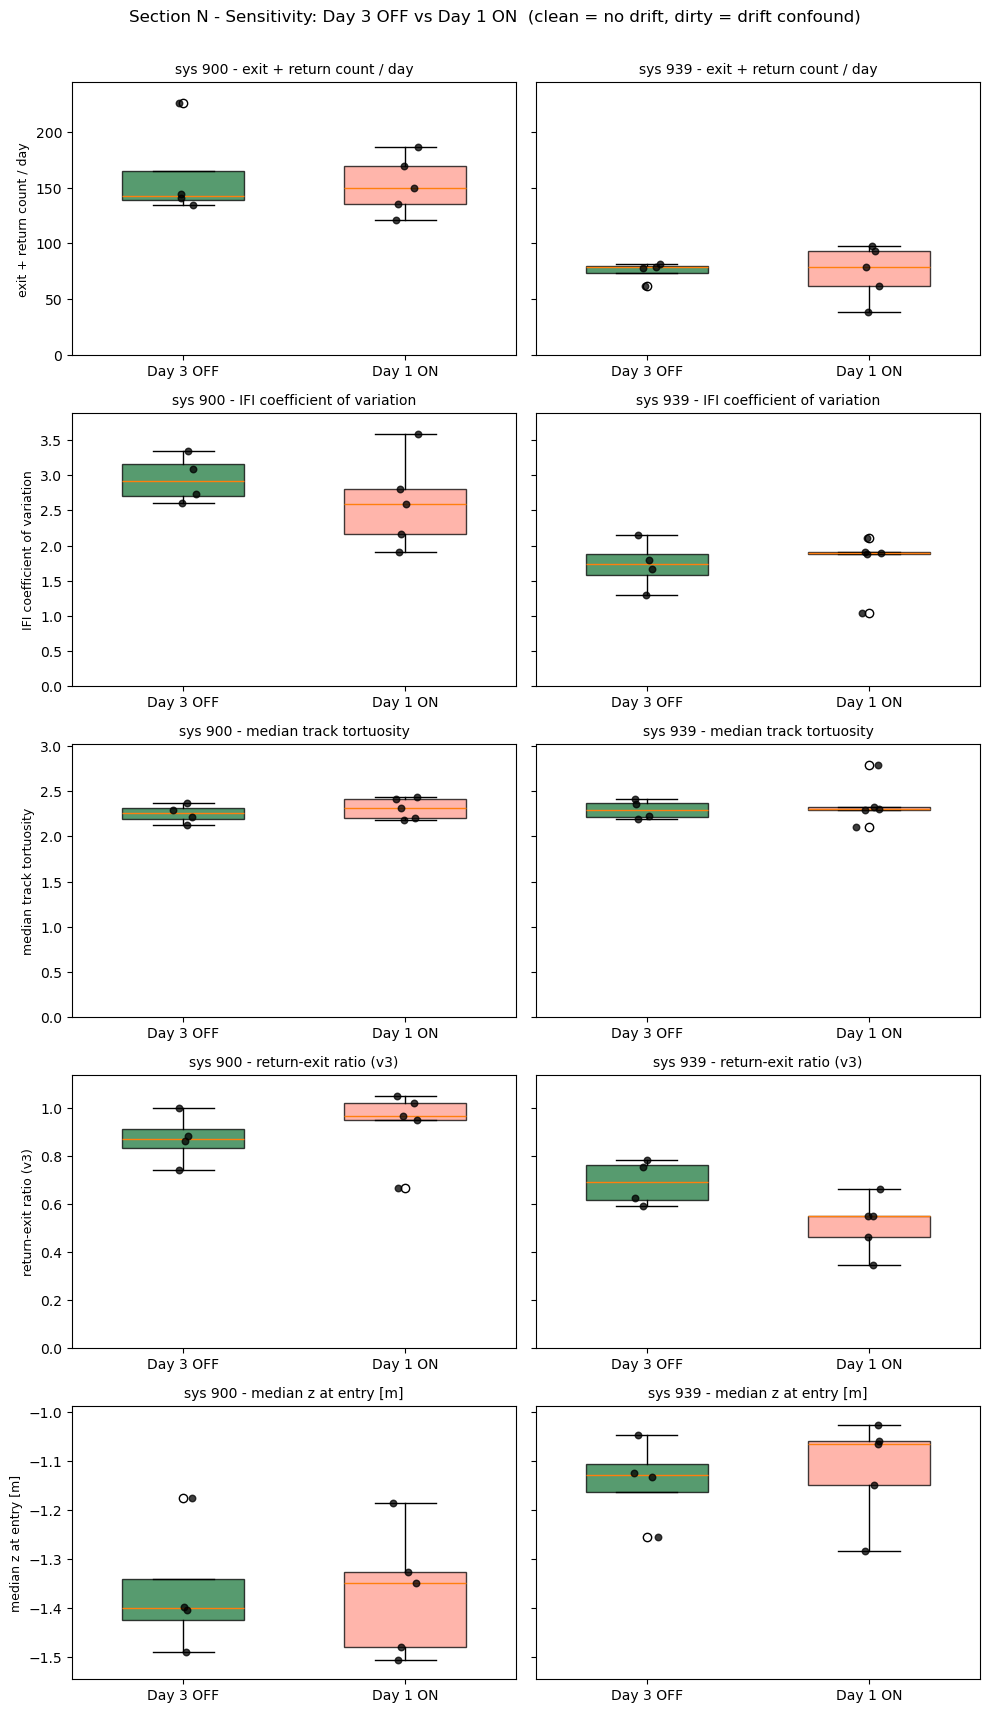


indicator               sys  D3OFF med   D1ON med   p (MWU)  n_d3off  n_d1on
  exit_return_count     900    142.500    150.000     1.000        4       5
  exit_return_count     939     78.500     79.000     0.902        4       5
  ifi_cv                900      2.912      2.592     0.413        4       5
  ifi_cv                939      1.736      1.901     0.730        4       5
  path_tortuosity       900      2.253      2.312     0.556        4       5
  path_tortuosity       939      2.291      2.308     1.000        4       5
  re_ratio              900      0.872      0.965     0.413        4       5
  re_ratio              939      0.690      0.550     0.065        4       5
  vertical_behaviour    900     -1.401     -1.349     1.000        4       5
  vertical_behaviour    939     -1.129     -1.065     0.905        4       5

Clean comparisons (p > 0.05, no significant drift): 10 / 10 indicator-system pairs.
If most pairs are clean, the ON/OFF comparison is not just seasonal

In [32]:
# --- N.2 Boxplots Day-3 OFF vs Day-1 ON, per system, per indicator -------
SENS_INDICATORS = INDICATORS  # all 5 from Section K
GROUP_ORDER_N   = ["Day 3 OFF", "Day 1 ON"]
GROUP_COLORS_N  = {"Day 3 OFF": "#1f7a3f", "Day 1 ON": "#ff9c8f"}  # darkest OFF -> lightest ON

fig, axes = plt.subplots(len(SENS_INDICATORS), len(systems),
                         figsize=(5 * len(systems), 3.4 * len(SENS_INDICATORS)),
                         sharey="row", squeeze=False)
for r, (col, label, signed) in enumerate(SENS_INDICATORS):
    vals_all = sens_pair[col].dropna()
    if signed and len(vals_all):
        ymin, ymax = vals_all.min(), vals_all.max()
        pad = 0.08 * (ymax - ymin) if ymax > ymin else 0.05
        ylim = (ymin - pad, ymax + pad)
    else:
        ymax = vals_all.max() if len(vals_all) else 1
        ylim = (0, ymax * 1.08 if ymax > 0 else 1)
    for c_ax, sid in enumerate(systems):
        ax = axes[r, c_ax]
        sub = sens_pair[sens_pair["system_id"] == sid]
        data = [sub.loc[sub["group"] == g, col].dropna() for g in GROUP_ORDER_N]
        bp = ax.boxplot(data, tick_labels=GROUP_ORDER_N, patch_artist=True, widths=0.55)
        for patch, g in zip(bp["boxes"], GROUP_ORDER_N):
            patch.set_facecolor(GROUP_COLORS_N[g]); patch.set_alpha(0.75)
        for i, dvals in enumerate(data):
            ax.scatter(np.full(len(dvals), i + 1) + np.random.uniform(-0.06, 0.06, len(dvals)),
                       dvals, color="black", s=22, alpha=0.75, zorder=3)
        ax.set_title(f"sys {sid} - {label}", fontsize=10)
        if c_ax == 0:
            ax.set_ylabel(label, fontsize=9)
        ax.set_ylim(*ylim)
fig.suptitle("Section N - Sensitivity: Day 3 OFF vs Day 1 ON  (clean = no drift, dirty = drift confound)",
             y=1.005)
plt.tight_layout()
plt.show()

# Stats
print(f"\n{'indicator':22s} {'sys':>4s} {'D3OFF med':>10s} {'D1ON med':>10s} "
      f"{'p (MWU)':>9s} {'n_d3off':>8s} {'n_d1on':>7s}")
clean_count = 0
total_count = 0
for col, label, _ in SENS_INDICATORS:
    for sid in systems:
        sub = sens_pair[sens_pair["system_id"] == sid]
        d3o = sub.loc[sub["group"] == "Day 3 OFF", col].dropna()
        d1o = sub.loc[sub["group"] == "Day 1 ON",  col].dropna()
        if len(d3o) and len(d1o):
            try:
                p = mannwhitneyu(d3o, d1o, alternative="two-sided").pvalue
            except ValueError:
                p = float("nan")
            total_count += 1
            if not np.isnan(p) and p > 0.05:
                clean_count += 1
        else:
            p = float("nan")
        print(f"  {col:20s} {sid:>4d} {d3o.median():>10.3f} {d1o.median():>10.3f} "
              f"{p:>9.3f} {len(d3o):>8d} {len(d1o):>7d}")
print(f"\nClean comparisons (p > 0.05, no significant drift): "
      f"{clean_count} / {total_count} indicator-system pairs.")
print("If most pairs are clean, the ON/OFF comparison is not just seasonal drift.")


# Section O - Dose-response analysis (dBm)

The strongest possible evidence for a 5G effect would be a **dose-response** relationship: more transmitter power -> more behavioural change.  Rather than just ON-vs-OFF as a binary, we use the actual continuous power level (dBm) from the Grafana export.

Pipeline:

1. Load the Grafana CSV (expected at `data/grafana_power.csv` with columns `ts` and `dBm`, optionally `mbps`).  If missing, the section is skipped with a clear note.
2. Aggregate to **mean dBm per (date, hour)**.
3. Aggregate each Tier-1 indicator to per-(date, system, hour), restricted to **ON hours only** (hours where dBm > some floor, indicating the transmitter was actually on).
4. For each Tier-1 indicator: scatterplot of indicator vs mean dBm with regression line, and Spearman correlation.

A significant negative Spearman r (more dBm -> lower exits / more tortuous paths / more dispersed IFI) is the strongest evidence of a 5G effect that this dataset can produce.


In [33]:
# --- O.1 Load Grafana data (skip section if file missing) ----------------
GRAFANA_CANDIDATES = [
    Path("../../../data/Power_levels_(dBm).csv"),
    Path("data/grafana_power.csv"),
    Path("../../../data/grafana_power.csv"),
    Path("../../../data/grafana/grafana_power.csv"),
]
grafana_path = next((p for p in GRAFANA_CANDIDATES if p.exists()), None)

if grafana_path is None:
    print("No Grafana power CSV found.  Searched:")
    for p in GRAFANA_CANDIDATES:
        print(f"  {p.resolve()}")
    print("\nSection O will be skipped.  Place a CSV with columns "
          "[ts, dBm, (optional) mbps] at one of the locations above and re-run.")
    grafana_hourly = None
else:
    print(f"Loading Grafana data from {grafana_path}")
    g = pd.read_csv(grafana_path)
    # Be permissive about column names
    ts_col = next((c for c in g.columns if c.lower() in {"ts", "timestamp", "time"}), g.columns[0])
    dbm_col = next((c for c in g.columns if "dbm" in c.lower()),
                   next((c for c in g.columns if "power" in c.lower()), None))
    if dbm_col is None:
        raise ValueError(f"Could not find a dBm/power column in {grafana_path}; got {g.columns.tolist()}")
    g["ts"] = pd.to_datetime(g[ts_col], errors="coerce")
    g["ts"] = (g["ts"].dt.tz_localize("Europe/Amsterdam") if g["ts"].dt.tz is None
               else g["ts"].dt.tz_convert("Europe/Amsterdam"))
    g = g.dropna(subset=["ts"])
    g["date"] = g["ts"].dt.date
    g["hour"] = g["ts"].dt.hour
    grafana_hourly = (g.groupby(["date", "hour"])[dbm_col]
                       .mean()
                       .rename("dBm_mean")
                       .reset_index())
    grafana_hourly["date"] = pd.to_datetime(grafana_hourly["date"])
    print(f"Hourly Grafana rows: {len(grafana_hourly)}  "
          f"({grafana_hourly['dBm_mean'].min():.1f} - {grafana_hourly['dBm_mean'].max():.1f} dBm)")


Loading Grafana data from ../../../data/Power_levels_(dBm).csv
Hourly Grafana rows: 793  (-30.7 - 13.0 dBm)


In [34]:
# --- O.2 Build per-(date, system, hour) Tier-1 indicators (ON hours only) -
if grafana_hourly is None:
    print("Skipping O.2 - no Grafana data.")
else:
    # Hourly v3-exit counts (already used in Section F, rebuild here for clarity)
    twh = tracks[tracks["hive_exit_v3"] == True].copy()
    twh["hour"]  = twh["ts"].dt.hour
    twh["date"]  = pd.to_datetime(twh["ts"].dt.date)

    hourly_exits = (twh.groupby(["date", "system_id", "hour"]).size()
                       .rename("exit_count").reset_index())

    # Hourly tortuosity (median over tracks present in that hour)
    twh_tort = tracks.copy()
    twh_tort["hour"] = twh_tort["ts"].dt.hour
    twh_tort["date"] = pd.to_datetime(twh_tort["ts"].dt.date)
    hourly_tort = (twh_tort.dropna(subset=["tortuosity"])
                            .groupby(["date", "system_id", "hour"])["tortuosity"]
                            .median()
                            .rename("path_tortuosity")
                            .reset_index())

    # Hourly IFI CV (std / mean within the hour)
    ex = exits.dropna(subset=["ifi_s"]).copy()
    ex["hour"] = ex["ts"].dt.hour
    ex["date"] = pd.to_datetime(ex["ts"].dt.date)
    hourly_ifi = (ex.groupby(["date", "system_id", "hour"])["ifi_s"]
                    .agg(["mean", "std", "count"])
                    .reset_index())
    hourly_ifi["ifi_cv"] = np.where(
        (hourly_ifi["mean"] > 0) & (hourly_ifi["count"] >= 2),
        hourly_ifi["std"] / hourly_ifi["mean"], np.nan,
    )

    # exit_return_count per hour: exits + returns
    rets = tracks[tracks["hive_return"] == True].copy()
    rets["hour"] = rets["ts"].dt.hour
    rets["date"] = pd.to_datetime(rets["ts"].dt.date)
    hourly_rets = (rets.groupby(["date", "system_id", "hour"]).size()
                       .rename("return_count").reset_index())

    hourly_dose = (hourly_exits
                   .merge(hourly_rets, on=["date", "system_id", "hour"], how="outer")
                   .merge(hourly_tort, on=["date", "system_id", "hour"], how="outer")
                   .merge(hourly_ifi[["date", "system_id", "hour", "ifi_cv"]],
                          on=["date", "system_id", "hour"], how="outer"))
    hourly_dose["exit_count"]   = hourly_dose["exit_count"].fillna(0)
    hourly_dose["return_count"] = hourly_dose["return_count"].fillna(0)
    hourly_dose["exit_return_count"] = hourly_dose["exit_count"] + hourly_dose["return_count"]
    hourly_dose["condition"] = hourly_dose["date"].apply(condition_for)

    # Join Grafana
    hourly_dose = hourly_dose.merge(grafana_hourly,
                                    on=["date", "hour"], how="left")

    # ON hours only.  We define "ON hour" as hour in an ON-day with dBm above
    # the median of all observed ON-day dBm values (i.e. transmitter actually broadcasting).
    on_rows = hourly_dose[(hourly_dose["condition"] == "ON")
                          & hourly_dose["dBm_mean"].notna()]
    if len(on_rows) == 0:
        print("No Grafana rows joined to ON-condition hours.  Cannot compute dose-response.")
    else:
        floor = on_rows["dBm_mean"].median() - 30  # 30 dB below median = noise floor
        on_rows = on_rows[on_rows["dBm_mean"] > floor]
        # restrict to active foraging window (same as Section F)
        on_rows = on_rows[on_rows["hour"].between(9, 15)]
        print(f"ON-condition hourly rows with Grafana dBm: {len(on_rows)}")
        print(f"dBm range used: {on_rows['dBm_mean'].min():.1f} - {on_rows['dBm_mean'].max():.1f}")


ON-condition hourly rows with Grafana dBm: 169
dBm range used: -20.2 - 12.0


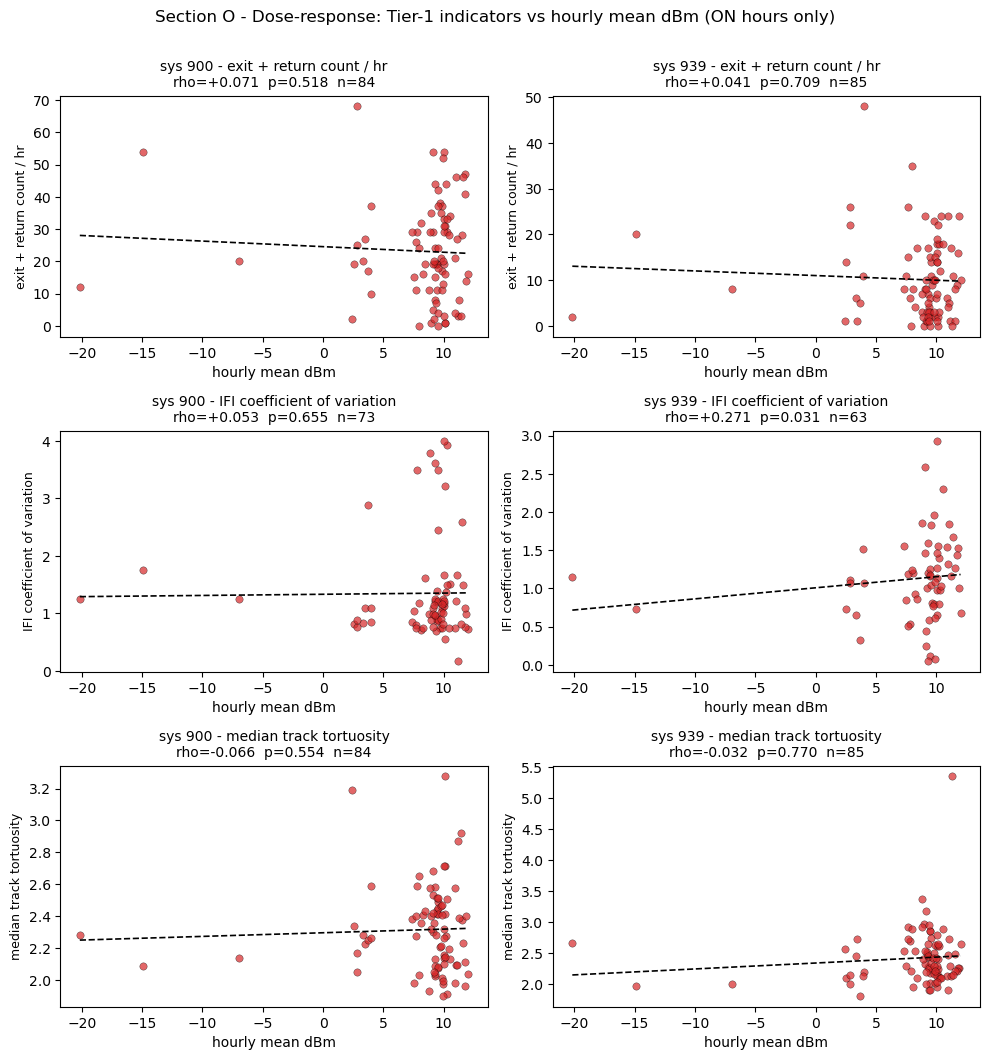


Section O - dose-response summary:
 sys indicator                   rho        p     n  flag
  900 exit_return_count        +0.071    0.518    84
  939 exit_return_count        +0.041    0.709    85
  900 ifi_cv                   +0.053    0.655    73
  939 ifi_cv                   +0.271    0.031    63
  900 path_tortuosity          -0.066    0.554    84
  939 path_tortuosity          -0.032    0.770    85


In [35]:
# --- O.3 Scatter + Spearman: each Tier-1 indicator vs hourly mean dBm ----
DOSE_INDICATORS = [
    ("exit_return_count", "exit + return count / hr"),
    ("ifi_cv",            "IFI coefficient of variation"),
    ("path_tortuosity",   "median track tortuosity"),
]

if grafana_hourly is None:
    print("Skipping O.3 - no Grafana data.")
elif len(on_rows) == 0:
    print("Skipping O.3 - no ON-hour Grafana rows.")
else:
    from scipy.stats import spearmanr

    fig, axes = plt.subplots(len(DOSE_INDICATORS), len(systems),
                              figsize=(5 * len(systems), 3.5 * len(DOSE_INDICATORS)),
                              squeeze=False)
    summary = []
    for r, (col, label) in enumerate(DOSE_INDICATORS):
        for c_ax, sid in enumerate(systems):
            ax = axes[r, c_ax]
            sub = on_rows[(on_rows["system_id"] == sid)].dropna(subset=[col, "dBm_mean"])
            if len(sub) >= 3:
                rho, p = spearmanr(sub["dBm_mean"], sub[col])
                ax.scatter(sub["dBm_mean"], sub[col], color=COLORS["ON"],
                           edgecolor="black", linewidth=0.3, s=28, alpha=0.7)
                # Linear regression line over the visible range
                if sub["dBm_mean"].nunique() >= 2:
                    z = np.polyfit(sub["dBm_mean"], sub[col], 1)
                    xs = np.linspace(sub["dBm_mean"].min(), sub["dBm_mean"].max(), 100)
                    ax.plot(xs, np.polyval(z, xs), color="black", lw=1.2, ls="--")
                ax.set_title(f"sys {sid} - {label}\nrho={rho:+.3f}  p={p:.3f}  n={len(sub)}",
                             fontsize=10)
                summary.append({"system_id": sid, "indicator": col,
                                "rho": rho, "p": p, "n": len(sub)})
            else:
                ax.set_title(f"sys {sid} - {label}\n(n<3)", fontsize=10)
                summary.append({"system_id": sid, "indicator": col,
                                "rho": float("nan"), "p": float("nan"), "n": len(sub)})
            ax.set_xlabel("hourly mean dBm")
            ax.set_ylabel(label, fontsize=9)
    fig.suptitle("Section O - Dose-response: Tier-1 indicators vs hourly mean dBm (ON hours only)",
                 y=1.005)
    plt.tight_layout()
    plt.show()

    dose_summary = pd.DataFrame(summary)
    print("\nSection O - dose-response summary:")
    print(f"{'sys':>4s} {'indicator':22s} {'rho':>8s} {'p':>8s} {'n':>5s}  flag")
    for _, row in dose_summary.iterrows():
        flag = ""
        if not np.isnan(row["rho"]):
            if row["p"] < 0.05 and row["rho"] < 0:
                flag = "  *** NEG dose-response (p<0.05)"
            elif abs(row["rho"]) > 0.3:
                flag = f"  |rho|>0.3 ({'NEG' if row['rho']<0 else 'POS'})"
        print(f"  {int(row['system_id']):>2d} {row['indicator']:22s} "
              f"{row['rho']:>+8.3f} {row['p']:>8.3f} {int(row['n']):>5d}{flag}")


# Section P - Putting Sections J - O together

Sections A - I established what we know **statically**: ON vs OFF differs in some indicators directionally, but no individual hour or daily metric survives BH at q=0.05 with 6 vs 6 days.  Sections J - O attack the question from five different angles to triangulate signal vs noise:

- **J - Temperature overlay.**  If the daily exit curve visually tracks daytime mean T regardless of ON/OFF condition, the binary contrast in Section C is partially confounded with weather.  The Spearman rho printed at the bottom of J.2 quantifies this; high (>0.5) means weather is the dominant driver.

- **K - Indicator dashboard.**  Five indicators, one figure, MWU + BH + rank-biserial r per system.  **Any indicator with |r| > 0.3 is flagged "directional"** even without significance, because at n=6 vs 6 only enormous effects can clear BH.  Cross-system agreement (both 900 and 939 same direction) matters more than any single p-value.

- **L - Heading dispersion (R).**  Lower mean resultant length R under ON would indicate directional confusion.  The permutation test gives a p-value for the ON-vs-OFF R difference.  This is independent of the magnitude indicators in K.

- **M - Accumulation (Day 1 vs Day 3 of ON block).**  If Day 3 ON is suppressed *more* than Day 1 ON, the effect is cumulative.  Severely underpowered (n=2 cycles), so look at direction, not p-values.

- **N - Sensitivity check (Day 3 OFF vs Day 1 ON).**  If these are statistically indistinguishable, the ON/OFF contrast in K isn't just seasonal drift.  Conversely, *significant* differences here would invalidate Sections C and K, since the bees are already drifting before exposure starts.

- **O - Dose-response.**  The cleanest possible test: continuous dBm vs hourly indicator.  A significant **negative** Spearman rho is the strongest evidence this dataset can produce.  Requires a Grafana export at `data/grafana_power.csv` (or an alternative path - see O.1).

**Interpretation rubric for the writeup:**

1. *Both Sections K and O show consistent direction across systems and at least one indicator with |r| > 0.3 (K) or rho < -0.3 (O)?*  -> directional signal worth reporting.
2. *Section L shows R_ON < R_OFF in both systems for at least one heading indicator?*  -> separate evidence of directional confusion.
3. *Section M shows Day 3 ON < Day 1 ON for the same indicators where K showed |r| > 0.3?*  -> consistent with a cumulative effect (but n=2).
4. *Section N is "clean" (>= half the indicator-system pairs have p > 0.05)?*  -> ON/OFF contrast survives the drift critique.
5. *Section J's Spearman rho between exits and T is high (>0.5)?*  -> weather is a real confound; report indicators in `weather_join.ipynb` *residualised* form before claiming a 5G effect.

If 1, 2, and 4 all hold, the writeup can claim a directional 5G signal subject to the n-limited power floor.  If 1 holds but 4 fails, the dataset cannot separate 5G from drift.  If only 5 holds (high T-correlation), the dataset cannot separate 5G from weather.
